# Loans at Risk: Capturing Default — Validation

## Purpose

This notebook implements the validation stage of the *Loans at Risk: Capturing Default* project. The analysis uses aligned datasets derived from the same underlying loan population:

- **Training set:** loans issued between 2007 and 2014  
- **Testing set:** loans issued in 2015  

The modeling population is restricted to loans with terminal outcomes in order to define a clear prediction target. The purpose of this notebook is **not to train or compare predictive models**, but to evaluate whether the selected model can be used to support **lending decisions** and whether it provides an improvement over LendingClub’s internal grading system. Specifically, this notebook assesses how predicted default probabilities translate into **acceptance policies**, **risk outcomes**, and **capital trade-offs**.

---

## Data Coverage and Baseline Scope

The modeling and validation analysis is restricted to loans with **application-time information** and a **clear observed repayment outcome**. This implies that the supervised modeling population consists of loans that were **approved and issued by LendingClub** and later observed to a terminal outcome. In principle, evaluating LendingClub’s broader approval process would require access to rejected applications as well. Archived rejected-loan files appear to exist, but repeated download attempts produced source-side errors, so these data could not be incorporated into the project. As a result, the analysis is conducted on the population of loans that LendingClub chose to accept and that can be observed to completion. This has two implications:

- The model is trained and evaluated on loans with observable terminal outcomes, consistent with the project’s prediction boundary.
- The comparison with LendingClub’s internal grading system is therefore a comparison **within the accepted loan population**, not a full evaluation of LendingClub’s initial approval boundary across all applicants.

Accordingly, the notebook does not claim to reproduce or replace LendingClub’s complete underwriting process. Instead, it evaluates whether default risk can be more effectively ordered and managed within the set of loans that LendingClub chose to accept.

---

## Data Sources

The validation analysis combines two dataset representations derived from the same underlying loan population:

- **Selected model input datasets**  
  The datasets `selected_model_input_train.parquet` and `selected_model_input_test.parquet` contain the fully engineered feature space used by the final selected model. These datasets are loaded into `df_model_input_train` and `df_model_input_test`. The trained model is applied to these datasets within this notebook to generate predicted default probabilities at the time of application. These predictions form the basis for all subsequent validation analyses. The underlying feature engineering and model training steps are not repeated here. This notebook operates on the finalized model and its inputs to produce a consistent validation dataset.

- **`clean` datasets**  
  These datasets retain LendingClub’s internal grading system and contextual variables, including loan amount, that are required for decision-system comparison and capital evaluation.

Both dataset representations share a common row identifier (`row_id`), which is used to align model predictions with LendingClub grades and observed outcomes. This alignment produces a unified validation dataset in which each loan is associated with:

- predicted default probability (model)  
- LendingClub grade (baseline system)  
- observed repayment outcome  
- loan characteristics relevant for decision evaluation  

This structure allows direct comparison between model-based and grade-based decision policies on the same set of loans.

---

## Analytical Framing

The modeling phase established that default risk can be predicted from application-time borrower information and identified a candidate model. Validation shifts the focus from prediction to **decision use**.
A predictive model is only useful if it enables better decisions than existing alternatives. In this context, the relevant benchmark is LendingClub’s internal **grade-based risk classification**, which implicitly defines how borrower risk is evaluated at the time of application. The central question becomes:

> Can a probability-based model improve lending outcomes relative to a grade-based policy when applied at the time of application?

Answering this requires translating model outputs into **operating policies** and evaluating their consequences.

---

## Decision Framework

Predicted default probabilities are converted into lending decisions using **threshold-based policies**. For a given threshold:

- Loans with predicted default probability below the threshold are **accepted**
- Loans with predicted default probability above the threshold are **rejected**

Different thresholds represent different lending strategies, ranging from conservative (low tolerance for default risk) to more permissive (higher acceptance rates with increased risk exposure). Model-based policies are evaluated across a range of thresholds to understand the trade-off between:

- **Default risk among accepted loans**
- **Volume of accepted loans**
- **False positives:** good loans rejected  
- **False negatives:** bad loans accepted  

These outcomes are compared directly to policies derived from **LendingClub grades**, which serve as the baseline decision system.

---

## Evaluation Dimensions

Validation focuses on three complementary dimensions:

#### 1. Risk Separation

- Assessed using ROC curves and AUC  
- Measures how well the model orders borrowers by risk  
- Compared to LendingClub’s grade-based system  
- Indicates ranking quality, not decision usefulness  

#### 2. Calibration

- Compares predicted probabilities to observed default rates  
- Evaluates whether probabilities reflect actual risk levels  
- Required for reliable threshold-based decisions  
- Miscalibration leads to systematic over- or underestimation of risk  

#### 3. Decision Outcomes

- Evaluates lending policies defined by probability thresholds  

For each threshold:

- Acceptance rate  
- Default rate among accepted loans  
- False positives (good loans rejected)  
- False negatives (bad loans accepted)  
- Loan volume and exposure  

Compared to LendingClub grade-based policies to assess whether the model:

- reduces default exposure  
- preserves or improves lending volume  
- improves the risk–opportunity trade-off  

---

## Stress Testing

In addition to standard evaluation, the model is tested on a **policy-exception population** that was excluded from model training. This provides a check on whether the model generalizes beyond the standard underwriting population and whether its decision signals remain stable under distributional shifts.

---

## Structure

The notebook proceeds in five stages.

1. **Model Outputs**  
   Load predictions from the selected model for both training and testing datasets.

2. **Baseline Definition**  
   Define LendingClub grade-based acceptance policies to serve as a benchmark.

3. **Risk Evaluation**  
   Assess risk separation (ROC/AUC) and calibration of predicted probabilities.

4. **Policy Simulation**  
   Evaluate threshold-based lending policies and compare outcomes to grade-based policies.

5. **Decision Synthesis**  
   Identify candidate operating thresholds and summarize trade-offs in terms of risk, volume, and capital exposure.

---

## Outcome

The goal of this notebook is to determine whether a model-based decision policy can **improve lending outcomes relative to existing grading practices**, and to define how such a model would be used in practice. The result is not a statement about model accuracy alone, but a **decision-oriented assessment** of whether and how the model should be deployed.

---

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()
project_root = None

for parent_path in (current_path, *current_path.parents):
    if (parent_path / "pyproject.toml").exists():
        project_root = parent_path
        break

if project_root is None:
    raise RuntimeError(
        f"Failed to resolve project root: pyproject.toml not found from {current_path}"
    )

src_path = project_root / "src"
if not src_path.exists():
    raise RuntimeError(f"Expected 'src' directory at: {src_path}")

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

{
    "stage": "bootstrap_import_path_ready",
    "project_root": str(project_root),
}

{'stage': 'bootstrap_import_path_ready',
 'project_root': 'D:\\Portfolio\\loans-at-risk-capturing-default'}

In [2]:
# ===========================================
# Imports: libraries and project modules
# ===========================================

from datetime import datetime, timezone
from typing import Callable
import uuid
import json

from IPython.display import display
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt

import config.logging as log_config
import validation.data as vd
import validation.metrics as vm
import validation.policy as vp
import analysis.validation_artifacts as va
import plots.validation_figures as vf
import plots.report_figures as rf


In [3]:

# ===============================
# Paths and run context
# ===============================

logs_root = project_root / "logs"
logs_root.mkdir(parents=True, exist_ok=True)

PROJECT_LOG_FILE = logs_root / "project.log"

run_id = uuid.uuid4().hex[:10]
run_timestamp_utc = datetime.now(timezone.utc)

run_header = (
    "NEW RUN: "
    f"{run_timestamp_utc.strftime('%Y-%m-%d %H:%M:%S')} UTC | "
    f"RUN_ID={run_id}"
)

log_config.log_messages("\n" + "=" * 60, PROJECT_LOG_FILE)
log_config.log_messages(run_header, PROJECT_LOG_FILE)
log_config.log_messages("=" * 60 + "\n", PROJECT_LOG_FILE)

log: Callable[[str], None] = log_config.get_logger(PROJECT_LOG_FILE)
log("Validation notebook initialized")
log(f"project_root: {project_root}")
log(run_header)

{
    "stage": "run_started",
    "run_id": run_id,
    "utc_timestamp": run_timestamp_utc.isoformat(),
}

# ---------------------------------------------------------------
# Inputs for this notebook (processed, report)
# ---------------------------------------------------------------

# Model input datasets (engineered)
selected_model_input_train_file = project_root / "data" / "processed" / "selected_model_input_train_data.parquet"
selected_model_input_test_file = project_root / "data" / "processed" / "selected_model_input_test_data.parquet"

# Clean datasets
clean_train_data_file = project_root / "data" / "interim" / "clean_loan_data_2007_2014.parquet"
clean_test_data_file = project_root / "data" / "interim" / "clean_loan_data_2015.parquet"

# Validation datasets (built in this notebook)
validation_train_file = project_root / "data" / "processed" / "validation_dataset_train.parquet"
validation_test_file = project_root / "data" / "processed" / "validation_dataset_test.parquet"

# Model artifact (selected model)
model_file = project_root / "models" / "catboost_shared_tuned.joblib"

# Metadata about the selected model and its performance
metadata_file = project_root / "data" / "processed" / "selected_model_metadata.json"

required_paths = {
    "selected_model_input_train_file": selected_model_input_train_file,
    "selected_model_input_test_file": selected_model_input_test_file,
    "clean_train_data_file": clean_train_data_file,
    "clean_test_data_file": clean_test_data_file,
    "selected_model_metadata_file": metadata_file,
}


# Validation artifacts directories
artifacts_dir = project_root / "artifacts"
validation_artifacts_dir = artifacts_dir / "validation"
validation_tables_dir = validation_artifacts_dir / "tables"
validation_figures_dir = validation_artifacts_dir / "figures"

validation_train_file.parent.mkdir(parents=True, exist_ok=True)
validation_test_file.parent.mkdir(parents=True, exist_ok=True)
validation_tables_dir.mkdir(parents=True, exist_ok=True)
validation_figures_dir.mkdir(parents=True, exist_ok=True)

report_figures_dir = artifacts_dir / "report" / "figures"
report_figures_dir.mkdir(parents=True, exist_ok=True)

log(f"Selected model train parquet path: {selected_model_input_train_file}")
log(f"Selected model test parquet path: {selected_model_input_test_file}")
log(f"Clean train parquet path: {clean_train_data_file}")
log(f"Clean test parquet path: {clean_test_data_file}")
log(f"Model metadata file path: {metadata_file}")
log(f"Validation tables directory: {validation_tables_dir}")
log(f"Validation figures directory: {validation_figures_dir}")
log(f"Report figures directory: {report_figures_dir}")

In [4]:
# ----------------------------------------------------------------
# Check that all required input paths exist before proceeding
# ----------------------------------------------------------------

missing_paths = {name: str(path) for name, path in required_paths.items() if not path.exists()}

if missing_paths:
    log(f"Missing required paths: {missing_paths}")
    raise FileNotFoundError(
        {
            "stage": "validation_path_check",
            "error": "missing_required_paths",
            "missing": missing_paths,
        }
    )

path_check = {
    "stage": "validation_path_check",
    "status": "ok",
}

log(f"Path check result: {path_check}")

path_check

{'stage': 'validation_path_check', 'status': 'ok'}

In [5]:
# --------------------------------------------------------
# Load validation inputs
# --------------------------------------------------------

# -----------------------------
# Load datasets
# -----------------------------
df_model_input_train = pd.read_parquet(selected_model_input_train_file).copy()
df_model_input_test = pd.read_parquet(selected_model_input_test_file).copy()

df_clean_train = pd.read_parquet(clean_train_data_file).copy()
df_clean_test = pd.read_parquet(clean_test_data_file).copy()

log("Loading validation datasets, model artifact, and metadata")

# -----------------------------
# Load model
# -----------------------------
model = joblib.load(model_file)

# -----------------------------
# Load metadata
# -----------------------------
with open(metadata_file, "r") as f:
    metadata = json.load(f)

log(f"Loaded model input train dataset: {df_model_input_train.shape}")
log(f"Loaded model input test dataset: {df_model_input_test.shape}")
log(f"Loaded clean train dataset: {df_clean_train.shape}")
log(f"Loaded clean test dataset: {df_clean_test.shape}")
log(f"Loaded model artifact: {type(model).__name__}")
log(f"Loaded model metadata for: {metadata.get('selected_model')}")

required_metadata_keys = [
    "selected_model",
    "model_family",
    "preprocessing_branch",
    "target_column",
    "row_identifier",
    "train_data_path",
    "test_data_path",
]

missing_metadata_keys = [
    key for key in required_metadata_keys if key not in metadata
]

structural_checks = {
    "stage": "validation_inputs_loaded",
    "model_loaded": model is not None,
    "model_type": type(model).__name__,
    "model_has_predict_proba": hasattr(model, "predict_proba"),
    "model_input_train_rows": df_model_input_train.shape[0],
    "model_input_test_rows": df_model_input_test.shape[0],
    "clean_train_rows": df_clean_train.shape[0],
    "clean_test_rows": df_clean_test.shape[0],
    "model_input_train_has_row_id": "row_id" in df_model_input_train.columns,
    "model_input_test_has_row_id": "row_id" in df_model_input_test.columns,
    "clean_train_has_row_id": "row_id" in df_clean_train.columns,
    "clean_test_has_row_id": "row_id" in df_clean_test.columns,
    "model_input_train_has_target": metadata.get("target_column") in df_model_input_train.columns,
    "model_input_test_has_target": metadata.get("target_column") in df_model_input_test.columns,
    "clean_train_has_target": metadata.get("target_column") in df_clean_train.columns,
    "clean_test_has_target": metadata.get("target_column") in df_clean_test.columns,
    "train_row_count_match": df_model_input_train.shape[0] == df_clean_train.shape[0],
    "test_row_count_match": df_model_input_test.shape[0] == df_clean_test.shape[0],
    "metadata_train_path_match": metadata.get("train_data_path") == str(selected_model_input_train_file),
    "metadata_test_path_match": metadata.get("test_data_path") == str(selected_model_input_test_file),
    "missing_metadata_keys": missing_metadata_keys,
}

log(str(structural_checks))

structural_checks

{'stage': 'validation_inputs_loaded',
 'model_loaded': True,
 'model_type': 'CatBoostClassifier',
 'model_has_predict_proba': True,
 'model_input_train_rows': 282945,
 'model_input_test_rows': 60012,
 'clean_train_rows': 466287,
 'clean_test_rows': 421095,
 'model_input_train_has_row_id': True,
 'model_input_test_has_row_id': True,
 'clean_train_has_row_id': True,
 'clean_test_has_row_id': True,
 'model_input_train_has_target': True,
 'model_input_test_has_target': True,
 'clean_train_has_target': False,
 'clean_test_has_target': False,
 'train_row_count_match': False,
 'test_row_count_match': False,
 'metadata_train_path_match': True,
 'metadata_test_path_match': True,
 'missing_metadata_keys': ['row_identifier']}

## Clean Population Alignment

The validation stage combines two data representations with different roles. The **model-input datasets** define the population on which the model operates. They are restricted to loans with terminal outcomes and match the population used during modeling. Predicted default probabilities are generated by applying the trained model to these datasets. The **clean datasets** retain the original variables required for interpretation and decision analysis, such as LendingClub grade and raw loan amount. These datasets are not restricted to the modeling population and therefore contain additional observations. Before validation, both representations must be aligned to the same row universe.

---

### Alignment

Validation is performed only on loans for which model predictions are available. The clean dataset is therefore restricted to the set of `row_id`s present in the model-input dataset. All other rows are removed. This produces a dataset that:
- matches the modeled population exactly  
- retains all contextual variables  
- avoids mixing raw and transformed representations  

---

### Target

The model-input datasets contain the binary target. The clean datasets do not. If the target is not present, it is reconstructed from `loan_status` using the same mapping applied during modeling. This ensures consistency between training and validation.

---

### Result

The final validation dataset:
- contains the same loans as the model-input dataset  
- includes the target variable  
- retains LendingClub grades and contextual features  

This dataset is used for all subsequent validation steps.

In [6]:
# ---------------------------------------------------------------------------------
# Prepare clean validation datasets by aligning clean and model input datasets
# ---------------------------------------------------------------------------------

df_clean_validation_train = vd.prepare_clean_validation_data(
    df_clean=df_clean_train,
    df_model_input=df_model_input_train,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log("Preparing clean validation dataset (train)")


df_clean_validation_test = vd.prepare_clean_validation_data(
    df_clean=df_clean_test,
    df_model_input=df_model_input_test,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log("Preparing clean validation dataset (test)")

{
    "stage": "clean_validation_dataset_prepared",
    "train_rows": df_clean_validation_train.shape[0],
    "test_rows": df_clean_validation_test.shape[0],
    "train_has_target": metadata["target_column"] in df_clean_validation_train.columns,
    "test_has_target": metadata["target_column"] in df_clean_validation_test.columns,
}

{'stage': 'clean_validation_dataset_prepared',
 'train_rows': 282945,
 'test_rows': 60012,
 'train_has_target': True,
 'test_has_target': True}

## 1. Model Outputs

The validation dataset contains outcomes and contextual variables but does not yet include model predictions. The trained model is applied to the engineered model-input datasets to generate predicted default probabilities for each loan. These predictions reflect the estimated probability of default at the time of application. The model-input datasets are used exclusively for scoring, as they contain the transformed feature space required by the model. The resulting predictions are then aligned with the clean validation dataset using `row_id`. This produces a unified dataset in which each loan is associated with:
- predicted default probability  
- observed outcome (`target_default`)  
- LendingClub grade  
- loan characteristics (e.g. loan amount)  

This dataset forms the basis for all subsequent validation analyses.

In [7]:
# --------------------------------------------------------------------------------------------------------------------
# Build validation datasets by merging clean validation datasets with model input datasets and adding predictions
# --------------------------------------------------------------------------------------------------------------------

df_validation_train = vd.build_validation_dataset(
    df_model_input=df_model_input_train,
    df_clean=df_clean_validation_train,
    model=model,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log(f"Validation dataset built (train): {df_validation_train.shape}")

df_validation_test = vd.build_validation_dataset(
    df_model_input=df_model_input_test,
    df_clean=df_clean_validation_test,
    model=model,
    target_column=metadata["target_column"],
    row_identifier_column="row_id",
    log=log,
)

log(f"Validation dataset built (test): {df_validation_test.shape}")

{
    "stage": "validation_dataset_built",
    "train_rows": df_validation_train.shape[0],
    "test_rows": df_validation_test.shape[0],
    "train_columns": df_validation_train.shape[1],
    "test_columns": df_validation_test.shape[1],
    "train_has_predictions": bool(df_validation_train["predicted_default_probability"].notna().all()),
	"test_has_predictions": bool(df_validation_test["predicted_default_probability"].notna().all()),
}

{'stage': 'validation_dataset_built',
 'train_rows': 282945,
 'test_rows': 60012,
 'train_columns': 92,
 'test_columns': 92,
 'train_has_predictions': True,
 'test_has_predictions': True}

In [8]:
# --------------------------------------------------------
# Save validation datasets
# --------------------------------------------------------

df_validation_train.to_parquet(validation_train_file)
df_validation_test.to_parquet(validation_test_file)

log(f"Validation dataset saved (train): {validation_train_file}")
log(f"Validation dataset saved (test): {validation_test_file}")

{
    "stage": "validation_dataset_saved",
    "train_path": str(validation_train_file),
    "test_path": str(validation_test_file),
    "train_rows": df_validation_train.shape[0],
    "test_rows": df_validation_test.shape[0],
}

{'stage': 'validation_dataset_saved',
 'train_path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\data\\processed\\validation_dataset_train.parquet',
 'test_path': 'D:\\Portfolio\\loans-at-risk-capturing-default\\data\\processed\\validation_dataset_test.parquet',
 'train_rows': 282945,
 'test_rows': 60012}

## Model Outputs — Summary

Predicted default probabilities were generated using the selected model and aligned with the clean validation datasets via `row_id`. The resulting dataset associates each loan with:
- predicted default probability  
- observed outcome (`target_default`)  
- LendingClub grade  
- loan characteristics (e.g. loan amount)  

These datasets are persisted to ensure that all subsequent analysis operates on a stable and reproducible base. The validation datasets now represent the full decision context: model predictions, realized outcomes, and the baseline system.

---

### Next Step

The next section evaluates **risk separation**. This assesses whether the model provides a stronger ordering of borrower risk than LendingClub’s grade-based system, using ROC curves and AUC.

---

## 2. Baseline Definition

In [9]:
# --------------------------------------------------------
# Summarize grade structure in validation datasets
# --------------------------------------------------------

df_grade_structure_train, df_subgrade_distribution_train = vd.summarize_grade_structure(
    df=df_validation_train,
    grade_column="grade",
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "grade_structure_summarized",
        "split": "train",
        "grade_rows": df_grade_structure_train.shape[0],
        "grade_columns": df_grade_structure_train.shape[1],
        "subgrade_rows": df_subgrade_distribution_train.shape[0],
        "subgrade_columns": df_subgrade_distribution_train.shape[1],
        "grades": df_grade_structure_train["grade"].tolist(),
    }
)

df_grade_structure_test, df_subgrade_distribution_test = vd.summarize_grade_structure(
    df=df_validation_test,
    grade_column="grade",
    subgrade_column="sub_grade",
    log=log,
)

log(
    {
        "stage": "grade_structure_summarized",
        "split": "test",
        "grade_rows": df_grade_structure_test.shape[0],
        "grade_columns": df_grade_structure_test.shape[1],
        "subgrade_rows": df_subgrade_distribution_test.shape[0],
        "subgrade_columns": df_subgrade_distribution_test.shape[1],
        "grades": df_grade_structure_test["grade"].tolist(),
    }
)

df_grade_structure_table = va.build_grade_structure_table(
    df_grade_structure_train=df_grade_structure_train,
    df_grade_structure_test=df_grade_structure_test,
    split_column="split",
    split_order=("train", "test"),
    log=log,
)

df_subgrade_distribution_table = va.build_subgrade_distribution_artifact_table(
    df_subgrade_distribution_train=df_subgrade_distribution_train,
    df_subgrade_distribution_test=df_subgrade_distribution_test,
    split_column="split",
    grade_column="grade",
    subgrade_column="sub_grade",
    count_column="loan_count",
    split_order=("train", "test"),
    log=log,
)

subgrade_distribution_table_file = (
    validation_tables_dir / "subgrade_distribution_table.csv"
)

df_subgrade_distribution_table.to_csv(subgrade_distribution_table_file, index=False)

log(
    {
        "stage": "subgrade_distribution_table_saved",
        "path": str(subgrade_distribution_table_file),
        "rows": df_subgrade_distribution_table.shape[0],
        "columns": df_subgrade_distribution_table.shape[1],
    }
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(
        df_grade_structure_table[
            [
                "split",
                "grade",
                "loan_count",
                "distinct_subgrades",
                "missing_subgrade_count",
                "missing_subgrade_rate",
            ]
        ].sort_values(["split", "grade"])
    )

    display(
        df_subgrade_distribution_table.sort_values(["split", "grade"])
    )

,split,grade,loan_count,distinct_subgrades,missing_subgrade_count,missing_subgrade_rate
0,train,a,47409,5,0,0.0
1,train,b,87183,5,0,0.0
2,train,c,72413,5,0,0.0
3,train,d,45044,5,0,0.0
4,train,e,20564,5,0,0.0
5,train,f,8177,5,0,0.0
6,train,g,2155,5,0,0.0
7,test,a,8116,5,0,0.0
8,test,b,14323,5,0,0.0
9,test,c,17400,5,0,0.0


,split,grade,a1,a2,a3,a4,a5,b1,b2,b3,b4,b5,c1,c2,c3,c4,c5,d1,d2,d3,d4,d5,e1,e2,e3,e4,e5,f1,f2,f3,f4,f5,g1,g2,g3,g4,g5
7,train,a,6784,6913,8037,12209,13466,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,train,b,0,0,0,0,0,13958,17108,20901,19400,15816,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,train,c,0,0,0,0,0,0,0,0,0,0,16651,15787,14295,13358,12322,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10,train,d,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11103,10185,8871,8151,6734,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
11,train,e,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5016,5005,4012,3534,2997,0,0,0,0,0,0,0,0,0,0
12,train,f,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2362,1868,1681,1267,999,0,0,0,0,0
13,train,g,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,726,525,365,283,256
0,test,a,1113,1289,1225,1825,2664,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,test,b,0,0,0,0,0,2378,2595,2830,3261,3259,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,test,c,0,0,0,0,0,0,0,0,0,0,3596,3665,3526,3599,3014,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
# -----------------------------------------------------------------------
# Build, save, and display normalized subgrade distribution artifact
# -----------------------------------------------------------------------

df_subgrade_distribution_normalized = va.build_normalized_subgrade_distribution_table(
    df_subgrade_distribution_table=df_subgrade_distribution_table,
    split_column="split",
    grade_column="grade",
    log=log,
)

log(
    {
        "stage": "subgrade_distribution_normalized_built",
        "rows": df_subgrade_distribution_normalized.shape[0],
        "columns": df_subgrade_distribution_normalized.shape[1],
    }
)

subgrade_distribution_normalized_file = (
    validation_tables_dir / "subgrade_distribution_normalized_table.csv"
)

df_subgrade_distribution_normalized.to_csv(
    subgrade_distribution_normalized_file,
    index=False,
)

log(
    {
        "stage": "subgrade_distribution_normalized_saved",
        "path": str(subgrade_distribution_normalized_file),
    }
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_subgrade_distribution_normalized)

,split,grade,a1,a2,a3,a4,a5,b1,b2,b3,b4,b5,c1,c2,c3,c4,c5,d1,d2,d3,d4,d5,e1,e2,e3,e4,e5,f1,f2,f3,f4,f5,g1,g2,g3,g4,g5
0,train,a,0.143095,0.145816,0.169525,0.257525,0.284039,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,train,b,0.000000,0.000000,0.000000,0.000000,0.000000,0.160100,0.196231,0.239737,0.222520,0.181412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,train,c,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.229945,0.218013,0.197409,0.184470,0.170163,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,train,d,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.246492,0.226112,0.196941,0.180956,0.149498,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,train,e,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.243921,0.243387,0.195098,0.171854,0.145740,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,train,f,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.288859,0.228446,0.205577,0.154947,0.122172,0.000000,0.000000,0.000000,0.000000,0.000000
6,train,g,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.336891,0.243619,0.169374,0.131323,0.118794
7,test,a,0.137137,0.158822,0.150936,0.224864,0.328241,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,test,b,0.000000,0.000000,0.000000,0.000000,0.000000,0.166027,0.181177,0.197584,0.227676,0.227536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,test,c,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.206667,0.210632,0.202644,0.206839,0.173218,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


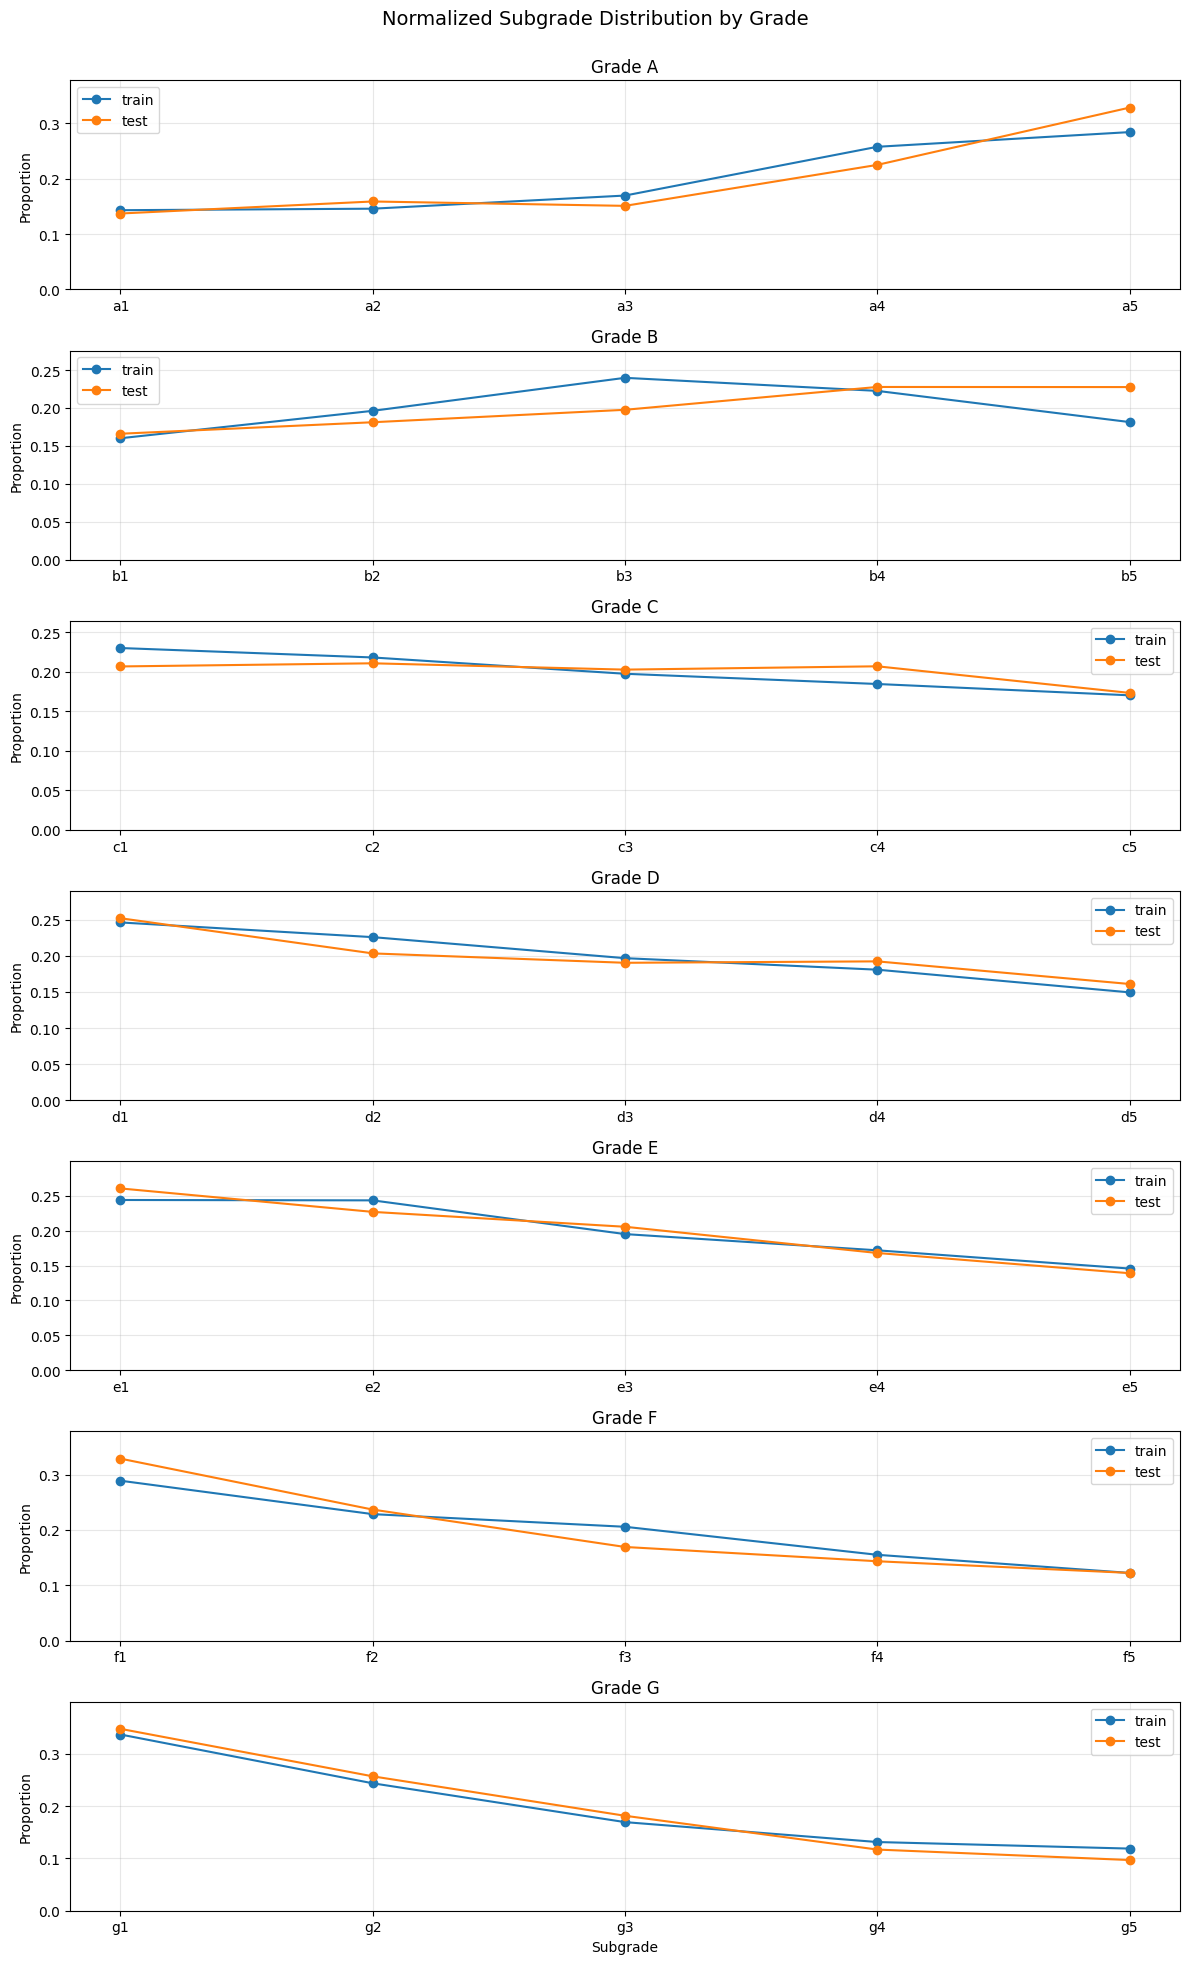

In [11]:
# --------------------------------------------------------
# Build, save, and display normalized subgrade distribution figure
# --------------------------------------------------------

figure_subgrade_distribution = vf.plot_normalized_subgrade_distribution_by_grade(
    df_subgrade_distribution_normalized=df_subgrade_distribution_normalized,
    split_column="split",
    grade_column="grade",
    log=log,
)

log(
    {
        "stage": "normalized_subgrade_distribution_figure_built",
        "rows": df_subgrade_distribution_normalized.shape[0],
        "columns": df_subgrade_distribution_normalized.shape[1],
    }
)

subgrade_distribution_figure_file = (
    validation_figures_dir / "normalized_subgrade_distribution_by_grade.png"
)

figure_subgrade_distribution.savefig(
    subgrade_distribution_figure_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "normalized_subgrade_distribution_figure_saved",
        "path": str(subgrade_distribution_figure_file),
    }
)

## Baseline Structure: Grade and Subgrade System

The grade-system summary shows that `sub_grade` is fully populated across both training and testing datasets. Each grade contains exactly five subgrades, with no missing values. Within each grade, loans are not evenly distributed across subgrades. The distributions are normalized, so values represent the share of loans within each grade. The patterns are asymmetric:

- Higher-quality grades (e.g. A) are skewed toward higher-index subgrades (e.g. `a4`, `a5`), indicating that many loans are close to the boundary with the next grade rather than concentrated at the lowest-risk end (`a1`).
- Lower-quality grades (D–G) show the opposite pattern, with more loans in lower-index subgrades (e.g. `d1`, `g1`), meaning fewer loans occupy the extreme high-risk tail (`g5`).
- Intermediate grades (B and C) are more evenly distributed.

This indicates that the grading system is not symmetric. Higher-quality grades are used more broadly, while lower-quality grades are more selective at the upper-risk end. These patterns are consistent across training and testing datasets, suggesting a stable grading structure rather than a sampling effect. An important implication is that subgrades are not equally sized. Moving a threshold across subgrades does not result in equal changes in loan volume. Overall, `sub_grade` represents a consistent internal ranking system and is used as the baseline for comparison.

In [12]:
# ----------------------------------------------------------------------------
# Compute, build, summarize, and save default rate by subgrade artifacts
# ----------------------------------------------------------------------------

default_rate_by_subgrade_frames: list[pd.DataFrame] = []

for split_name, df_validation in [
    ("train", df_validation_train),
    ("test", df_validation_test),
]:
    df_default_rate_by_subgrade = vd.compute_default_rate_by_subgrade(
        df_validation=df_validation,
        target_column=metadata["target_column"],
        subgrade_column="sub_grade",
        log=log,
    )

    log(
        {
            "stage": "default_rate_by_subgrade_computed",
            "split": split_name,
            "rows": df_default_rate_by_subgrade.shape[0],
            "columns": df_default_rate_by_subgrade.shape[1],
        }
    )

    default_rate_by_subgrade_frames.append(df_default_rate_by_subgrade)

df_default_rate_by_subgrade_table = va.build_default_rate_by_subgrade_artifact_table(
    df_default_rate_by_subgrade_train=default_rate_by_subgrade_frames[0],
    df_default_rate_by_subgrade_test=default_rate_by_subgrade_frames[1],
    split_column="split",
    subgrade_column="sub_grade",
    split_order=("train", "test"),
    log=log,
)

log(
    {
        "stage": "default_rate_by_subgrade_table_built",
        "rows": df_default_rate_by_subgrade_table.shape[0],
        "columns": df_default_rate_by_subgrade_table.shape[1],
    }
)

default_rate_by_subgrade_table_file = (
    validation_tables_dir / "default_rate_by_subgrade_table.csv"
)

df_default_rate_by_subgrade_table.to_csv(
    default_rate_by_subgrade_table_file,
    index=False,
)

log(
    {
        "stage": "default_rate_by_subgrade_table_saved",
        "path": str(default_rate_by_subgrade_table_file),
    }
)

df_default_rate_by_subgrade_summary = va.summarize_default_rate_by_subgrade_table(
    df_default_rate_by_subgrade_table=df_default_rate_by_subgrade_table,
    split_column="split",
    default_rate_column="default_rate",
    split_order=("train", "test"),
    log=log,
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_default_rate_by_subgrade_summary)

,split,count,mean,std,min,25%,50%,75%,max
0,train,35.0,0.269599,0.137771,0.030808,0.150912,0.268403,0.386440,0.463014
1,test,35.0,0.257082,0.150860,0.018868,0.121322,0.266452,0.373355,0.555556


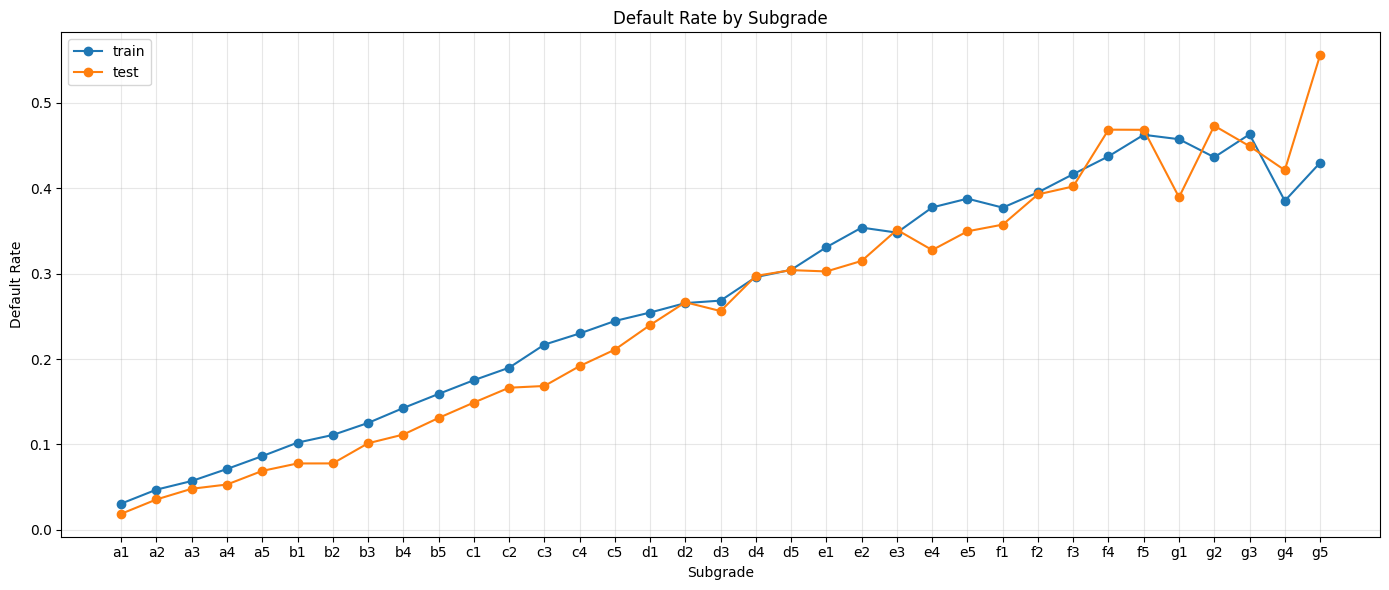

In [13]:
# --------------------------------------------------------
# Build, save, and display default rate by subgrade figure
# --------------------------------------------------------

figure_default_rate_by_subgrade = vf.plot_default_rate_by_subgrade(
    df_default_rate_by_subgrade=df_default_rate_by_subgrade_table,
    split_column="split",
    subgrade_column="sub_grade",
    default_rate_column="default_rate",
    log=log,
)

log(
    {
        "stage": "default_rate_by_subgrade_figure_built",
        "rows": df_default_rate_by_subgrade_table.shape[0],
        "columns": df_default_rate_by_subgrade_table.shape[1],
    }
)

default_rate_by_subgrade_figure_file = (
    validation_figures_dir / "default_rate_by_subgrade.png"
)

figure_default_rate_by_subgrade.savefig(
    default_rate_by_subgrade_figure_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "default_rate_by_subgrade_figure_saved",
        "path": str(default_rate_by_subgrade_figure_file),
    }
)

display(figure_default_rate_by_subgrade)
plt.close(figure_default_rate_by_subgrade)

## Baseline Structure Conclusion

The LendingClub grade system provides a structured and stable baseline for risk classification. Subgrades are fully populated and consistently applied across both training and testing datasets. The internal distribution of loans within grades is non-uniform and asymmetric, meaning that thresholds based on subgrades do not translate into uniform changes in loan volume. Observed default rates confirm that `sub_grade` represents a meaningful risk ordering. Default risk increases substantially from `a1` to `g5`, and this pattern is consistent across datasets. While the highest-risk subgrades show some variability due to smaller sample sizes, the overall structure remains stable. This indicates that the baseline system already captures a substantial portion of the available risk signal. As a result, the model is not competing against a weak baseline. Any improvement must come from refining the ordering within and across subgrades, particularly in regions where risk is concentrated. The baseline is therefore evaluated at the `sub_grade` level, providing a complete and operationally relevant ranking of borrowers.

---

## 3. Risk Evaluation

This section evaluates the selected model from two complementary perspectives:

1. **Risk separation**  
   → how effectively the model orders borrowers from lower to higher risk relative to LendingClub’s internal ranking  

2. **Calibration**  
   → whether predicted default probabilities correspond to observed default rates  

Together, these determine whether the model produces both a strong risk ordering and usable probability estimates before policy evaluation. Risk separation is evaluated by comparing the model’s predicted probabilities to the subgrade-based baseline. ROC curves and AUC are computed for both systems on training and testing data to assess how well each orders borrowers by default risk.

---

In [14]:
# ----------------------------------------------------------------------
# Compute, save, and display ROC/AUC artifacts for model and subgrade baseline (train → test)
# ----------------------------------------------------------------------

# Model ROC/AUC
roc_model_frames: list[pd.DataFrame] = []

for split_name, df_validation in [
    ("train", df_validation_train),
    ("test", df_validation_test),
]:
    df_roc_model = vm.compute_model_roc_auc(
        y_true=df_validation[metadata["target_column"]],
        y_score=df_validation["predicted_default_probability"],
        system_name="model",
        dataset_name=split_name,
        log=log,
    )

    log(
        {
            "stage": "roc_model_computed",
            "split": split_name,
            "rows": df_roc_model.shape[0],
            "auc": float(df_roc_model["auc"].iloc[0]),
        }
    )

    roc_model_frames.append(df_roc_model)

# Baseline ROC/AUC
roc_baseline_frames: list[pd.DataFrame] = []

for split_name, df_validation in [
    ("train", df_validation_train),
    ("test", df_validation_test),
]:
    df_roc_baseline = vm.compute_baseline_roc_auc_from_subgrade(
        y_true=df_validation[metadata["target_column"]],
        subgrade_series=df_validation["sub_grade"],
        system_name="baseline_subgrade",
        dataset_name=split_name,
        log=log,
    )

    log(
        {
            "stage": "roc_baseline_computed",
            "split": split_name,
            "rows": df_roc_baseline.shape[0],
            "auc": float(df_roc_baseline["auc"].iloc[0]),
        }
    )

    roc_baseline_frames.append(df_roc_baseline)

# --------------------------------------------------------
# Build and save ROC artifacts
# --------------------------------------------------------

df_roc_curve_artifact = va.build_roc_curve_artifact_table(
    roc_auc_artifact_frames=roc_model_frames + roc_baseline_frames,
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    false_positive_rate_column="false_positive_rate",
    true_positive_rate_column="true_positive_rate",
    threshold_column="threshold",
    auc_column="auc",
    log=log,
)

log(
    {
        "stage": "roc_curve_artifact_built",
        "rows": df_roc_curve_artifact.shape[0],
        "columns": df_roc_curve_artifact.shape[1],
    }
)

df_risk_separation_summary = va.build_risk_separation_summary_table(
    roc_auc_artifact_df=df_roc_curve_artifact,
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    auc_column="auc",
    log=log,
)

log(
    {
        "stage": "risk_separation_summary_built",
        "rows": df_risk_separation_summary.shape[0],
        "columns": df_risk_separation_summary.shape[1],
    }
)

roc_curve_artifact_file = validation_tables_dir / "roc_curve_artifact.csv"
risk_separation_summary_file = validation_tables_dir / "risk_separation_summary.csv"

df_roc_curve_artifact.to_csv(
    roc_curve_artifact_file,
    index=False,
)

df_risk_separation_summary.to_csv(
    risk_separation_summary_file,
    index=False,
)

log(
    {
        "stage": "risk_separation_artifacts_saved",
        "roc_curve_path": str(roc_curve_artifact_file),
        "summary_path": str(risk_separation_summary_file),
    }
)

# --------------------------------------------------------
# Quick AUC sanity check (train → test)
# --------------------------------------------------------

df_auc_quick = va.build_auc_comparison_table(
    df_roc_model_train=roc_model_frames[0],
    df_roc_model_test=roc_model_frames[1],
    df_roc_baseline_train=roc_baseline_frames[0],
    df_roc_baseline_test=roc_baseline_frames[1],
    split_column="split",
    system_column="system",
    auc_column="auc",
    split_order=("train", "test"),
    system_order=("model", "baseline_subgrade"),
    log=log,
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_auc_quick)

,system,split,auc
0,model,train,0.748522
1,baseline_subgrade,train,0.678294
2,model,test,0.723228
3,baseline_subgrade,test,0.691944


### Risk Separation — Conclusion

The model improves risk separation relative to LendingClub’s grading system, indicating that additional predictive signal is available beyond the subgrade-based baseline. This means borrowers can be ordered more precisely by risk than under the existing grading system. The next step is to determine whether this improved ordering translates into better lending decisions, in terms of reduced default exposure and preserved lending volume.

---

### Calibration

Calibration assesses whether predicted default probabilities correspond to observed default rates. This is required for threshold-based decision-making, as probability estimates determine whether a given acceptance rule reflects the intended level of risk.

---

In [15]:
# ----------------------------------------------------------------------
# Compute, save, and display calibration artifacts (train → test)
# ----------------------------------------------------------------------

calibration_tables: list[pd.DataFrame] = []

for split_name, df_validation in [
    ("train", df_validation_train),
    ("test", df_validation_test),
]:
    df_calibration = vm.compute_calibration_table(
        y_true=df_validation[metadata["target_column"]],
        y_score=df_validation["predicted_default_probability"],
        system_name="model",
        dataset_name=split_name,
        n_bins=10,
        log=log,
    )

    log(
        {
            "stage": "calibration_table_computed",
            "split": split_name,
            "rows": df_calibration.shape[0],
            "columns": df_calibration.shape[1],
        }
    )

    calibration_tables.append(df_calibration)

df_calibration_artifact = va.build_calibration_artifact_table(
    calibration_tables=calibration_tables,
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    bin_order_column="bin_order",
    log=log,
)

log(
    {
        "stage": "calibration_artifact_built",
        "rows": df_calibration_artifact.shape[0],
        "columns": df_calibration_artifact.shape[1],
    }
)

calibration_artifact_file = validation_tables_dir / "calibration_artifact.csv"

df_calibration_artifact.to_csv(
    calibration_artifact_file,
    index=False,
)

log(
    {
        "stage": "calibration_artifact_saved",
        "path": str(calibration_artifact_file),
    }
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_calibration_artifact)

,system_name,dataset_name,bin_order,calibration_bin,row_count,predicted_probability_mean,observed_default_rate,predicted_probability_min,predicted_probability_max
0,model,train,1,"(0.0033, 0.0622]",28295,0.045029,0.031878,0.004305,0.062188
1,model,train,2,"(0.0622, 0.086]",28294,0.074422,0.059589,0.062189,0.086040
2,model,train,3,"(0.086, 0.108]",28295,0.097214,0.082347,0.086040,0.108285
3,model,train,4,"(0.108, 0.132]",28294,0.119754,0.106524,0.108285,0.131555
4,model,train,5,"(0.132, 0.157]",28295,0.144185,0.132356,0.131556,0.157478
5,model,train,6,"(0.157, 0.188]",28294,0.172115,0.164629,0.157479,0.187763
6,model,train,7,"(0.188, 0.226]",28294,0.206052,0.202658,0.187763,0.225857
7,model,train,8,"(0.226, 0.277]",28295,0.250235,0.251564,0.225859,0.277492
8,model,train,9,"(0.277, 0.362]",28294,0.315234,0.331554,0.277500,0.361656
9,model,train,10,"(0.362, 0.959]",28295,0.460568,0.522283,0.361662,0.959240


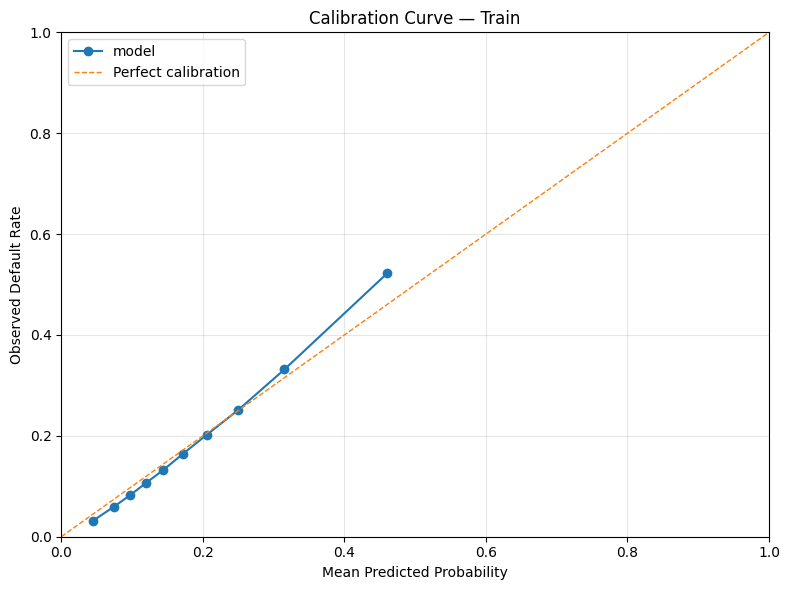

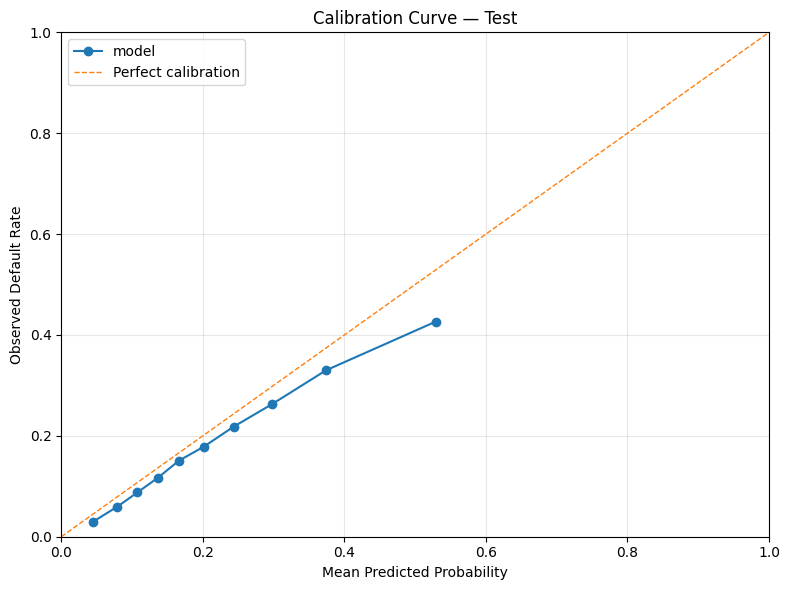

In [16]:
# ----------------------------------------------------------------------
# Build, save, and display calibration figures (train → test)
# ----------------------------------------------------------------------

for dataset_name in ["train", "test"]:
    figure_calibration = vf.plot_calibration_curve(
        df_calibration_artifact=df_calibration_artifact,
        dataset_name=dataset_name,
        system_name_column="system_name",
        dataset_name_column="dataset_name",
        predicted_probability_column="predicted_probability_mean",
        observed_default_rate_column="observed_default_rate",
        log=log,
    )

    calibration_figure_file = (
        validation_figures_dir / f"calibration_curve_{dataset_name}.png"
    )

    figure_calibration.savefig(
        calibration_figure_file,
        dpi=300,
        bbox_inches="tight",
    )

    log(
        {
            "stage": "calibration_curve_saved",
            "dataset": dataset_name,
            "path": str(calibration_figure_file),
        }
    )

    display(figure_calibration)
    plt.close(figure_calibration)

### Calibration — Conclusion

The model is reasonably well calibrated across the low-to-middle probability range in both training and testing data. Predicted default probabilities track observed default rates closely enough to support threshold-based evaluation. Calibration is less stable in the highest-risk region, where the relationship between predicted and observed risk becomes less consistent across datasets. As a result, decisions targeting the extreme upper tail should be interpreted with additional caution. Overall, the model provides probability estimates that are suitable for decision evaluation, with weaker reliability at the highest predicted risk levels.

---

## Risk Evaluation — Conclusion

The model demonstrates improved risk separation relative to the subgrade-based baseline, indicating that additional predictive signal is available beyond LendingClub’s grading system. This improvement is consistent across training and testing data, though more modest out of sample. Calibration results show that predicted default probabilities broadly align with observed default rates across the low-to-middle probability range. Calibration is less stable in the highest-risk region, where predicted and observed risk diverge more noticeably. Taken together, the model provides both a stronger risk ordering and probability estimates suitable for threshold-based decision-making, with reduced reliability in the upper tail. The next step is to evaluate whether these improvements translate into better lending decisions in terms of default risk and lending volume.

---

## 4. Policy Simulation

This section evaluates how the model and the subgrade-based baseline perform when translated into lending decisions. For a range of acceptance policies, both systems are used to simulate which loans would be approved or rejected. The resulting portfolios are compared in terms of default rates, error types, and loan exposure. This provides a direct assessment of how each approach trades off risk reduction against lending volume, and whether the model’s improvements translate into decision outcomes.

---

### Model Threshold Policies

Model-based lending policies are defined by probability thresholds. Loans with predicted default probability at or below the threshold are accepted, while loans above the threshold are rejected. Thresholds are evaluated on both training and testing data to assess how acceptance rules affect default risk, lending volume, and error trade-offs.

---

In [17]:
# ----------------------------------------------------------------------
# Model threshold policies (train → test)
# ----------------------------------------------------------------------

model_policy_thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]

model_policy_outcome_tables: list[pd.DataFrame] = []

for split_name, df_validation in [
    ("train", df_validation_train),
    ("test", df_validation_test),
]:
    for threshold_value in model_policy_thresholds:
        df_model_policy = vp.apply_model_threshold_policy(
            score_series=df_validation["predicted_default_probability"],
            threshold=threshold_value,
            log=log,
        )

        log(
            {
                "stage": "model_policy_applied",
                "split": split_name,
                "threshold": threshold_value,
                "rows": df_model_policy.shape[0],
            }
        )

        df_model_policy_outcome = vp.evaluate_policy_outcomes(
            y_true=df_validation[metadata["target_column"]],
            loan_amounts=df_validation["loan_amnt"],
            decision_dataframe=df_model_policy,
            policy_name="model_threshold",
            policy_value=threshold_value,
            dataset_name=split_name,
            log=log,
        )

        log(
            {
                "stage": "model_policy_outcomes_evaluated",
                "split": split_name,
                "threshold": threshold_value,
                "rows": df_model_policy_outcome.shape[0],
            }
        )

        model_policy_outcome_tables.append(df_model_policy_outcome)

df_model_policy_outcomes = va.build_model_policy_outcomes_artifact_table(
    model_policy_outcome_tables=model_policy_outcome_tables,
    dataset_name_column="dataset_name",
    policy_value_column="policy_value",
    dataset_order=("train", "test"),
    log=log,
)

log(
    {
        "stage": "model_policy_outcomes_combined",
        "rows": df_model_policy_outcomes.shape[0],
        "columns": df_model_policy_outcomes.shape[1],
    }
)

model_policy_outcomes_file = validation_tables_dir / "model_policy_outcomes.csv"

df_model_policy_outcomes.to_csv(
    model_policy_outcomes_file,
    index=False,
)

log(
    {
        "stage": "model_policy_outcomes_saved",
        "path": str(model_policy_outcomes_file),
    }
)

df_model_policy_outcomes_display = va.build_model_policy_outcomes_display_table(
    df_model_policy_outcomes=df_model_policy_outcomes,
    accepted_non_default_loan_amount_column="accepted_non_default_loan_amnt",
    accepted_default_loan_amount_column="accepted_default_loan_amnt",
    rejected_non_default_loan_amount_column="rejected_non_default_loan_amnt",
    net_value_proxy_column="net_value_proxy",
    net_value_proxy_with_opportunity_cost_column="net_value_proxy_with_opportunity_cost",
    log=log,
)

df_model_policy_outcomes_display = va.format_model_policy_outcomes_display_table(
    df_model_policy_outcomes_display=df_model_policy_outcomes_display,
    log=log,
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_model_policy_outcomes_display)

,policy_name,policy_value,dataset_name,accepted_count,rejected_count,acceptance_rate,default_rate_among_accepted,accepted_loan_amnt,accepted_default_loan_amnt,rejected_non_default_loan_amnt,net_value_proxy,net_value_proxy_with_opportunity_cost
0,model_threshold,0.05,train,16557,266388,5.85%,2.30%,"$209,367,000","$5,250,175","$2,861,297,350","$198,866,650","$-2,662,430,700"
1,model_threshold,0.10,train,74278,208667,26.25%,5.35%,"$941,568,750","$51,276,950","$2,175,122,375","$839,014,850","$-1,336,107,525"
2,model_threshold,0.15,train,133780,149165,47.28%,7.91%,"$1,680,756,550","$132,323,125","$1,516,980,750","$1,416,110,300","$-100,870,450"
3,model_threshold,0.20,train,179703,103242,63.51%,10.17%,"$2,270,520,750","$231,609,225","$1,026,502,650","$1,807,302,300","$780,799,650"
4,model_threshold,0.25,train,212432,70513,75.08%,12.00%,"$2,713,332,850","$328,689,325","$680,770,650","$2,055,954,200","$1,375,183,550"
5,model_threshold,0.30,train,235734,47211,83.31%,13.60%,"$3,051,367,700","$422,623,250","$436,669,725","$2,206,121,200","$1,769,451,475"
6,model_threshold,0.35,train,251716,31229,88.96%,14.88%,"$3,300,825,675","$504,712,950","$269,301,450","$2,291,399,775","$2,022,098,325"
7,model_threshold,0.40,train,262739,20206,92.86%,15.96%,"$3,483,017,450","$576,962,975","$159,359,700","$2,329,091,500","$2,169,731,800"
8,model_threshold,0.45,train,270387,12558,95.56%,16.84%,"$3,615,755,825","$638,733,725","$88,392,075","$2,338,288,375","$2,249,896,300"
9,model_threshold,0.05,test,3493,56519,5.82%,2.18%,"$45,128,550","$1,037,675","$661,895,350","$43,053,200","$-618,842,150"


In [18]:
# ----------------------------------------------------------------------
# Baseline subgrade policies (train → test)
# ----------------------------------------------------------------------

baseline_policy_cutoffs = ["a5", "b5", "c5", "d5", "e5", "f5", "g5"]

baseline_policy_outcome_tables: list[pd.DataFrame] = []

for split_name, df_validation in [
    ("train", df_validation_train),
    ("test", df_validation_test),
]:
    for cutoff_value in baseline_policy_cutoffs:
        df_baseline_policy = vp.apply_subgrade_cutoff_policy(
            subgrade_series=df_validation["sub_grade"],
            cutoff_subgrade=cutoff_value,
            log=log,
        )

        log(
            {
                "stage": "baseline_policy_applied",
                "split": split_name,
                "cutoff_subgrade": cutoff_value,
                "rows": df_baseline_policy.shape[0],
            }
        )

        df_baseline_policy_outcome = vp.evaluate_policy_outcomes(
            y_true=df_validation[metadata["target_column"]],
            loan_amounts=df_validation["loan_amnt"],
            decision_dataframe=df_baseline_policy,
            policy_name="baseline_subgrade",
            policy_value=cutoff_value,
            dataset_name=split_name,
            log=log,
        )

        log(
            {
                "stage": "baseline_policy_outcomes_evaluated",
                "split": split_name,
                "cutoff_subgrade": cutoff_value,
                "rows": df_baseline_policy_outcome.shape[0],
            }
        )

        baseline_policy_outcome_tables.append(df_baseline_policy_outcome)

df_baseline_policy_outcomes = va.build_baseline_policy_outcomes_artifact_table(
    baseline_policy_outcome_tables=baseline_policy_outcome_tables,
    dataset_name_column="dataset_name",
    policy_value_column="policy_value",
    dataset_order=("train", "test"),
    log=log,
)

log(
    {
        "stage": "baseline_policy_outcomes_combined",
        "rows": df_baseline_policy_outcomes.shape[0],
        "columns": df_baseline_policy_outcomes.shape[1],
    }
)

baseline_policy_outcomes_file = validation_tables_dir / "baseline_policy_outcomes.csv"

df_baseline_policy_outcomes.to_csv(
    baseline_policy_outcomes_file,
    index=False,
)

log(
    {
        "stage": "baseline_policy_outcomes_saved",
        "path": str(baseline_policy_outcomes_file),
    }
)

df_baseline_policy_outcomes_display = va.build_baseline_policy_outcomes_display_table(
    df_baseline_policy_outcomes=df_baseline_policy_outcomes,
    accepted_non_default_loan_amount_column="accepted_non_default_loan_amnt",
    accepted_default_loan_amount_column="accepted_default_loan_amnt",
    rejected_non_default_loan_amount_column="rejected_non_default_loan_amnt",
    net_value_proxy_column="net_value_proxy",
    net_value_proxy_with_opportunity_cost_column="net_value_proxy_with_opportunity_cost",
    log=log,
)

df_baseline_policy_outcomes_display = va.format_baseline_policy_outcomes_display_table(
    df_baseline_policy_outcomes_display=df_baseline_policy_outcomes_display,
    log=log,
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_baseline_policy_outcomes_display)

,policy_name,policy_value,dataset_name,accepted_count,rejected_count,acceptance_rate,default_rate_among_accepted,accepted_loan_amnt,accepted_default_loan_amnt,rejected_non_default_loan_amnt,net_value_proxy,net_value_proxy_with_opportunity_cost
0,baseline_subgrade,a5,train,47409,235536,16.76%,6.39%,"$598,643,625","$37,106,075","$2,503,876,625","$524,431,475","$-1,979,445,150"
1,baseline_subgrade,b5,train,134592,148353,47.57%,10.59%,"$1,692,268,900","$178,335,750","$1,551,481,025","$1,335,597,400","$-215,883,625"
2,baseline_subgrade,c5,train,207005,75940,73.16%,14.18%,"$2,663,182,400","$385,521,550","$787,753,325","$1,892,139,300","$1,104,385,975"
3,baseline_subgrade,d5,train,252049,30896,89.08%,16.56%,"$3,297,500,900","$567,031,825","$334,945,100","$2,163,437,250","$1,828,492,150"
4,baseline_subgrade,e5,train,272613,10332,96.35%,17.99%,"$3,649,722,625","$696,669,075","$112,360,625","$2,256,384,475","$2,144,023,850"
5,baseline_subgrade,f5,train,280790,2155,99.24%,18.66%,"$3,801,016,050","$760,098,550","$24,496,675","$2,280,818,950","$2,256,322,275"
6,baseline_subgrade,g5,train,282945,0,100.00%,18.85%,"$3,844,978,300","$779,564,125",$0,"$2,285,850,050","$2,285,850,050"
7,baseline_subgrade,a5,test,8116,51896,13.52%,5.01%,"$111,236,100","$5,528,350","$600,278,475","$100,179,400","$-500,099,075"
8,baseline_subgrade,b5,test,22439,37573,37.39%,8.34%,"$299,939,700","$24,948,200","$430,994,725","$250,043,300","$-180,951,425"
9,baseline_subgrade,c5,test,39839,20173,66.39%,12.39%,"$536,269,125","$66,974,100","$236,691,200","$402,320,925","$165,629,725"


In [19]:
# ----------------------------------------------------------------------
# Match baseline vs model by acceptance rate (test set)
# ----------------------------------------------------------------------

df_policy_comparison = va.build_matched_policy_comparison_table(
    df_model_policy_outcomes=df_model_policy_outcomes,
    df_baseline_policy_outcomes=df_baseline_policy_outcomes,
    dataset_name="test",
    dataset_name_column="dataset_name",
    policy_value_column="policy_value",
    acceptance_rate_column="acceptance_rate",
    default_rate_column="default_rate_among_accepted",
    accepted_non_default_loan_amount_column="accepted_non_default_loan_amnt",
    accepted_default_loan_amount_column="accepted_default_loan_amnt",
    rejected_non_default_loan_amount_column="rejected_non_default_loan_amnt",
    log=log,
)

log(
    {
        "stage": "policy_comparison_built",
        "rows": df_policy_comparison.shape[0],
        "columns": df_policy_comparison.shape[1],
    }
)

policy_comparison_file = validation_tables_dir / "policy_comparison_matched.csv"

df_policy_comparison.to_csv(policy_comparison_file, index=False)

log(
    {
        "stage": "policy_comparison_saved",
        "path": str(policy_comparison_file),
    }
)

df_policy_comparison_display = va.format_matched_policy_comparison_table(
    df_policy_comparison=df_policy_comparison,
    percentage_columns=[
        "baseline_acceptance_rate",
        "model_acceptance_rate",
        "acceptance_rate_diff",
        "baseline_default_rate",
        "model_default_rate",
        "default_rate_diff",
    ],
    money_columns=[
        "baseline_net_value_proxy",
        "baseline_net_value_with_opportunity_cost",
        "model_net_value_proxy",
        "model_net_value_with_opportunity_cost",
        "net_value_proxy_diff",
        "net_value_with_opportunity_cost_diff",
    ],
    log=log,
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_policy_comparison_display)

,baseline_policy,baseline_acceptance_rate,baseline_default_rate,baseline_net_value_proxy,baseline_net_value_with_opportunity_cost,model_threshold,model_acceptance_rate,model_default_rate,model_net_value_proxy,model_net_value_with_opportunity_cost,acceptance_rate_diff,default_rate_diff,net_value_proxy_diff,net_value_with_opportunity_cost_diff
0,a5,13.52%,5.01%,"$100,179,400","-$500,099,075",0.05,5.82%,2.18%,"$43,053,200","-$618,842,150",-7.70%,-2.84%,"-$57,126,200","-$118,743,075"
1,b5,37.39%,8.34%,"$250,043,300","-$180,951,425",0.15,39.73%,7.33%,"$264,371,850","-$153,866,075",2.34%,-1.02%,"$14,328,550","$27,085,350"
2,c5,66.39%,12.39%,"$402,320,925","$165,629,725",0.25,66.48%,11.38%,"$412,265,425","$180,721,725",0.09%,-1.02%,"$9,944,500","$15,092,000"
3,d5,84.17%,15.48%,"$476,951,975","$358,623,975",0.35,82.53%,14.29%,"$487,655,525","$370,623,300",-1.65%,-1.18%,"$10,703,550","$11,999,325"
4,e5,95.04%,17.44%,"$521,874,000","$485,660,200",0.45,91.67%,16.27%,"$521,247,900","$468,845,250",-3.38%,-1.16%,"-$626,100","-$16,814,950"
5,f5,98.92%,18.33%,"$531,519,925","$523,750,250",0.45,91.67%,16.27%,"$521,247,900","$468,845,250",-7.25%,-2.06%,"-$10,272,025","-$54,905,000"
6,g5,100.00%,18.61%,"$533,410,100","$533,410,100",0.45,91.67%,16.27%,"$521,247,900","$468,845,250",-8.33%,-2.34%,"-$12,162,200","-$64,564,850"


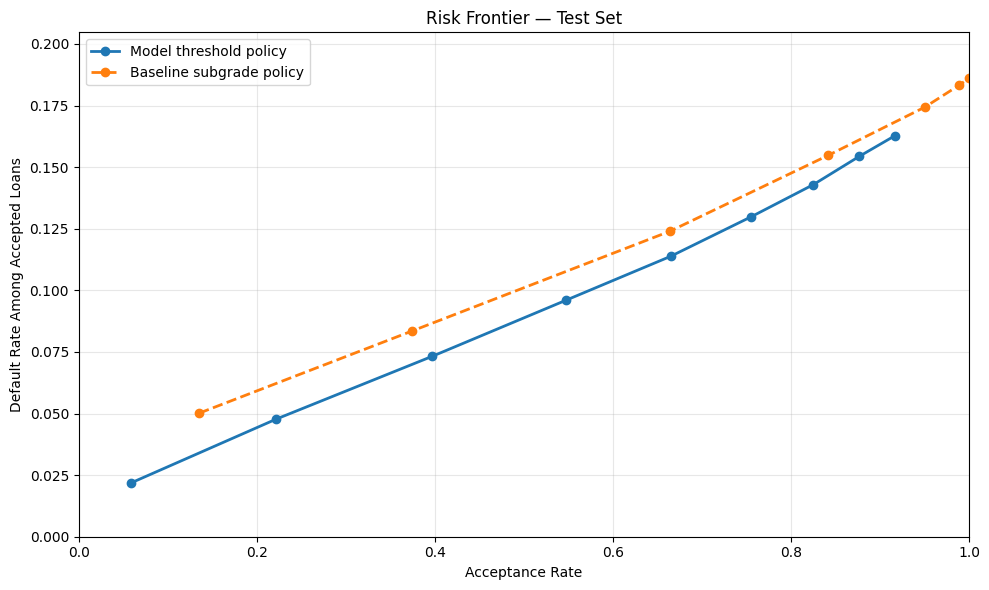

In [20]:
# ----------------------------------------------------------------------
# Policy frontier plot (acceptance vs default rate) — test set
# Report figure candidate
# ----------------------------------------------------------------------

figure_risk_frontier_test = vf.plot_policy_risk_frontier(
    df_model_policy_outcomes=df_model_policy_outcomes,
    df_baseline_policy_outcomes=df_baseline_policy_outcomes,
    dataset_name="test",
    dataset_name_column="dataset_name",
    acceptance_rate_column="acceptance_rate",
    default_rate_column="default_rate_among_accepted",
    model_label="Model threshold policy",
    baseline_label="Baseline subgrade policy",
    log=log,
)

risk_frontier_test_file = validation_figures_dir / "risk_frontier_test.png"

figure_risk_frontier_test.savefig(
    risk_frontier_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "risk_frontier_test_saved",
        "path": str(risk_frontier_test_file),
    }
)

display(figure_risk_frontier_test)
plt.close(figure_risk_frontier_test)

The model achieves consistently lower default rates at comparable acceptance levels, indicating stronger risk separation than the baseline across the core operating range.

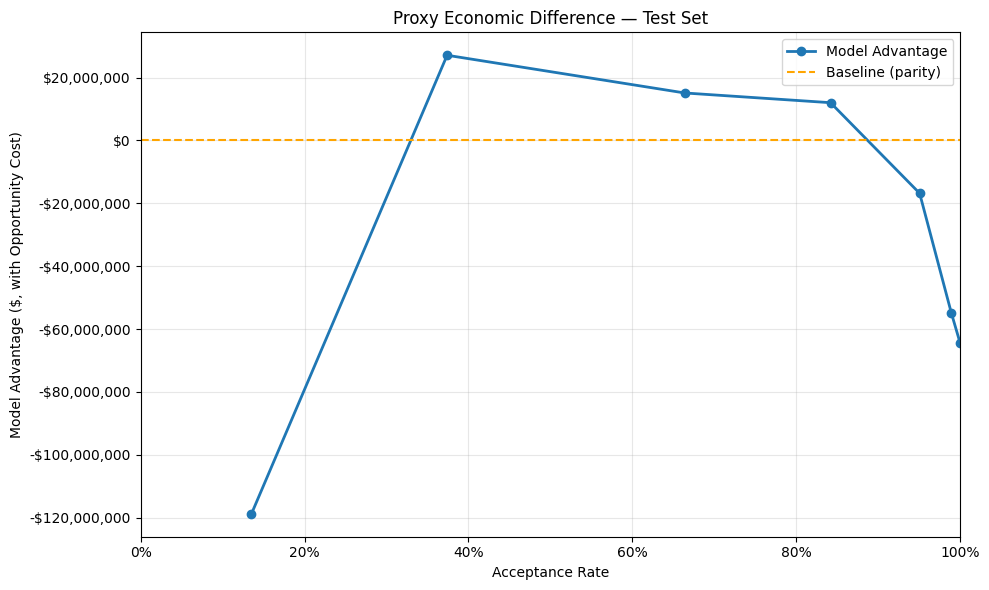

In [21]:
# ----------------------------------------------------------------------
# Proxy economic difference plot (model - baseline) — matched test policies
# ----------------------------------------------------------------------

figure_proxy_economic_difference_test = vf.plot_proxy_economic_difference(
    df_policy_comparison=df_policy_comparison,
    acceptance_rate_column="baseline_acceptance_rate",
    value_diff_column="net_value_with_opportunity_cost_diff",
    title="Proxy Economic Difference — Test Set",
    x_label="Acceptance Rate",
    y_label="Model Advantage ($, with Opportunity Cost)",
    log=log,
)

proxy_economic_difference_test_file = (
    validation_figures_dir / "proxy_economic_difference_test.png"
)

figure_proxy_economic_difference_test.savefig(
    proxy_economic_difference_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "proxy_economic_difference_test_saved",
        "path": str(proxy_economic_difference_test_file),
    }
)

display(figure_proxy_economic_difference_test)
plt.close(figure_proxy_economic_difference_test)

**Interpretation**

Positive values indicate that the model allocates capital more efficiently than the baseline at comparable acceptance levels, with the strongest advantage in the mid-range. The model achieves consistently lower default rates at comparable acceptance levels, indicating stronger risk separation across the core operating range.

---

## Policy Landscape

Both the model and the baseline define a trade-off between acceptance, risk, and capital allocation. As policies become more permissive, acceptance increases, default rates rise, and opportunity cost declines. This structure is consistent across both systems. The difference lies in how efficiently each system moves along this trade-off. The risk frontier shows that the model achieves lower default rates at comparable acceptance levels across the core operating range. This reflects a more precise ordering of borrower risk, allowing for better separation between higher- and lower-risk applicants at the time of application. This improvement in ranking translates into policy outcomes. At comparable acceptance levels, the model allocates capital more efficiently than the baseline in the mid-range, reducing exposure to defaulting loans while retaining more performing loans. The advantage is not uniform. At very low acceptance levels, the model is more conservative, increasing opportunity cost. At very high acceptance levels, both systems converge as acceptance approaches saturation, reducing the impact of improved ordering. Taken together, the model does not change the structure of the trade-off, but improves the efficiency with which it is navigated. The benefit is concentrated in the region where underwriting decisions are active, rather than at the extremes.

---

In [22]:
# ----------------------------------------------------------------------
# Policy-exception and pricing audit (train → test)
# ----------------------------------------------------------------------

df_policy_exception_summary = va.build_policy_exception_pricing_summary_table(
    df_validation_train=df_validation_train,
    df_validation_test=df_validation_test,
    target_column=metadata["target_column"],
    loan_status_column="loan_status",
    predicted_probability_column="predicted_default_probability",
    interest_rate_column="int_rate",
    loan_amount_column="loan_amnt",
    dataset_name_column="dataset_name",
    policy_exception_flag_column="policy_exception_flag",
    policy_group_column="policy_group",
    log=log,
)

log(
    {
        "stage": "policy_exception_summary_built",
        "rows": df_policy_exception_summary.shape[0],
        "columns": df_policy_exception_summary.shape[1],
    }
)

policy_exception_summary_file = (
    validation_tables_dir / "policy_exception_pricing_summary.csv"
)

df_policy_exception_summary.to_csv(
    policy_exception_summary_file,
    index=False,
)

log(
    {
        "stage": "policy_exception_summary_saved",
        "path": str(policy_exception_summary_file),
    }
)

df_policy_exception_comparison = va.build_policy_exception_pricing_comparison_table(
    df_policy_exception_summary=df_policy_exception_summary,
    dataset_name_column="dataset_name",
    policy_group_column="policy_group",
    log=log,
)

log(
    {
        "stage": "policy_exception_comparison_built",
        "rows": df_policy_exception_comparison.shape[0],
        "columns": df_policy_exception_comparison.shape[1],
    }
)

policy_exception_comparison_file = (
    validation_tables_dir / "policy_exception_pricing_comparison.csv"
)

df_policy_exception_comparison.to_csv(
    policy_exception_comparison_file,
    index=False,
)

log(
    {
        "stage": "policy_exception_comparison_saved",
        "path": str(policy_exception_comparison_file),
    }
)

df_policy_exception_summary_display = va.format_policy_exception_pricing_summary_table(
    df_policy_exception_summary=df_policy_exception_summary,
    log=log,
)

df_policy_exception_comparison_display = (
    va.format_policy_exception_pricing_comparison_table(
        df_policy_exception_comparison=df_policy_exception_comparison,
        log=log,
    )
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_policy_exception_summary_display)
    display(df_policy_exception_comparison_display)

,dataset_name,policy_group,row_count,population_share,observed_default_rate,predicted_default_probability_mean,int_rate_mean,int_rate_median,loan_amnt_mean,loan_amnt_median
0,train,standard_issued,280196,99.03%,18.77%,18.79%,13.78%,13.61%,"$13,634","$12,000"
1,train,policy_exception_issued,2749,0.97%,27.68%,24.46%,14.15%,14.18%,"$9,040","$7,500"
2,test,standard_issued,60012,100.00%,18.61%,21.81%,13.56%,13.33%,"$14,640","$12,500"


,dataset_name,row_count_standard_issued,row_count_policy_exception_issued,population_share_standard_issued,population_share_policy_exception_issued,observed_default_rate_standard_issued,observed_default_rate_policy_exception_issued,default_rate_gap,predicted_default_probability_mean_standard_issued,predicted_default_probability_mean_policy_exception_issued,predicted_risk_gap,int_rate_mean_standard_issued,int_rate_mean_policy_exception_issued,int_rate_mean_gap
0,train,280196.0,2749.0,99.03%,0.97%,18.77%,27.68%,8.92%,18.79%,24.46%,5.67%,13.78%,14.15%,0.37%
1,test,60012.0,NaN,100.00%,nan%,18.61%,nan%,nan%,21.81%,nan%,nan%,13.56%,nan%,nan%


## Policy Exceptions and Pricing Consistency

This section examines loans that were issued despite not meeting LendingClub’s stated credit policy. The objective is to assess whether these policy exceptions differ in risk and whether pricing reflects that difference. Policy exception loans represent a small share of the portfolio (~1% in the training data), but their behavior differs materially from standard-issued loans. The observed default rate increases from 18.77% to 27.68% (+8.92 pp), and the model assigns higher predicted risk (18.79% → 24.46%, +5.67 pp). This indicates that both realized outcomes and model-based estimates consistently identify these loans as higher risk. Pricing increases only marginally. The average interest rate rises from 13.78% to 14.15% (+0.37 pp), which is small relative to the increase in default risk. Policy exception loans are also issued at lower average amounts, suggesting partial mitigation through exposure size rather than pricing.

Taken together, this indicates a structural inconsistency. Higher-risk loans are both issued and recognized as such, but pricing does not adjust proportionally to the observed increase in risk. This suggests that policy overrides are systematically associated with higher-risk loans without a corresponding adjustment in pricing or exposure. In the test data, no policy exception loans are observed, indicating that this behavior is confined to earlier vintages. This finding supports the broader validation result: risk can be identified, but is not consistently translated into aligned decision and pricing behavior.

---

## Risk Stratification

Loans are grouped into risk bands based on predicted default probability, and observed default rates are compared across those bands. This establishes whether the model produces a meaningful risk ordering that can serve as a reference for assessing how pricing varies with risk.

---

In [23]:
# ----------------------------------------------------------------------
# Build, save, and display risk band summary artifact (test set)
# ----------------------------------------------------------------------

df_risk_band_summary_test = va.build_risk_band_summary_table(
    df_validation=df_validation_test,
    score_column="predicted_default_probability",
    target_column=metadata["target_column"],
    dataset_name="test",
    n_bands=10,
    log=log,
)

log(
    {
        "stage": "risk_band_summary_built",
        "dataset_name": "test",
        "rows": df_risk_band_summary_test.shape[0],
        "columns": df_risk_band_summary_test.shape[1],
    }
)

risk_band_summary_test_file = (
    validation_tables_dir / "risk_band_summary_test.csv"
)

df_risk_band_summary_test.to_csv(
    risk_band_summary_test_file,
    index=False,
)

log(
    {
        "stage": "risk_band_summary_saved",
        "dataset_name": "test",
        "path": str(risk_band_summary_test_file),
    }
)

# ----------------------------------------------------------------------
# Display (formatted)
# ----------------------------------------------------------------------

df_risk_band_summary_display = df_risk_band_summary_test.copy()

percentage_columns = [
    "predicted_default_probability_mean",
    "observed_default_rate",
]

for column_name in percentage_columns:
    df_risk_band_summary_display[column_name] = (
        df_risk_band_summary_display[column_name]
        .map(lambda value: f"{value:.2%}")
    )

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_risk_band_summary_display)

,risk_band,loan_count,predicted_default_probability_mean,observed_default_rate,dataset_name
0,"(0.007240000000000001, 0.0645]",6002,4.50%,2.98%,test
1,"(0.0645, 0.0938]",6001,7.94%,5.98%,test
2,"(0.0938, 0.122]",6001,10.77%,8.80%,test
3,"(0.122, 0.151]",6001,13.61%,11.65%,test
4,"(0.151, 0.183]",6001,16.65%,15.10%,test
5,"(0.183, 0.221]",6001,20.14%,17.85%,test
6,"(0.221, 0.268]",6001,24.35%,21.81%,test
7,"(0.268, 0.33]",6001,29.75%,26.26%,test
8,"(0.33, 0.427]",6001,37.41%,32.99%,test
9,"(0.427, 0.902]",6002,52.95%,42.67%,test


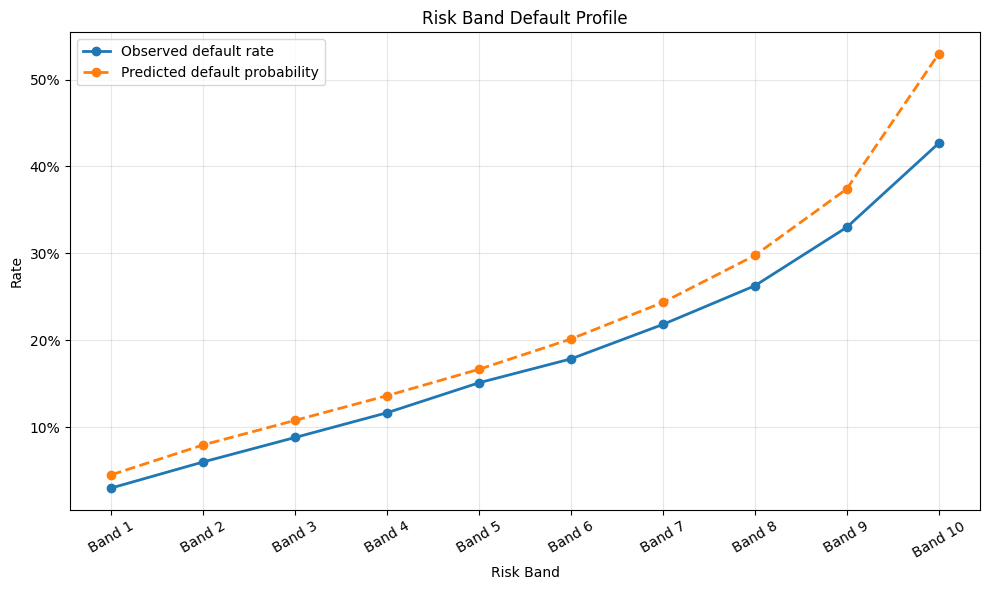

In [24]:
# ----------------------------------------------------------------------
# Build, save, and display risk band default profile figure (test set)
# ----------------------------------------------------------------------

figure_risk_band_default_profile_test = vf.plot_risk_band_default_profile(
    df_risk_band_summary=df_risk_band_summary_test,
    band_column="risk_band",
    observed_default_rate_column="observed_default_rate",
    predicted_risk_column="predicted_default_probability_mean",
    log=log,
)

risk_band_default_profile_test_file = (
    validation_figures_dir / "risk_band_default_profile_test.png"
)

figure_risk_band_default_profile_test.savefig(
    risk_band_default_profile_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "risk_band_default_profile_saved",
        "dataset_name": "test",
        "path": str(risk_band_default_profile_test_file),
    }
)

display(figure_risk_band_default_profile_test)
plt.close(figure_risk_band_default_profile_test)

**Interpretation**

The model produces a clear and monotonic risk ordering. As predicted default probability increases, observed default rates rise consistently across all bands, confirming that borrowers can be reliably ranked by risk. Predicted probabilities are generally higher than observed default rates, particularly in the upper bands. This indicates a conservative bias: the model tends to overestimate risk. While this reduces the likelihood of underestimating defaults, it also requires careful interpretation when applying thresholds. The spread in risk is substantial. Observed default rates increase from approximately 3% in the lowest band to over 40% in the highest band, reflecting a structural shift in borrower quality rather than a marginal increase in risk. This increase is non-linear. Risk rises gradually in the lower bands but accelerates in the upper bands, indicating that default exposure is concentrated in a relatively small portion of the portfolio. As a result, decisions in the higher-risk range have a disproportionate impact. This structure explains the earlier threshold results. Thresholds around 0.35–0.40 align with the point where risk begins to accelerate more sharply. Below this range, risk remains relatively controlled; above it, default exposure increases rapidly. Taken together, the model provides usable risk stratification. It establishes a stable reference for evaluating whether pricing and policy decisions are aligned with the underlying risk structure of the portfolio.

---

,risk_band,loan_count,predicted_default_probability_mean,observed_default_rate,int_rate_mean,int_rate_median,dataset_name
0,"(0.007240000000000001, 0.0645]",6002,4.50%,2.98%,8.22%,7.89%,test
1,"(0.0645, 0.0938]",6001,7.94%,5.98%,10.08%,9.49%,test
2,"(0.0938, 0.122]",6001,10.77%,8.80%,11.19%,10.99%,test
3,"(0.122, 0.151]",6001,13.61%,11.65%,12.10%,12.29%,test
4,"(0.151, 0.183]",6001,16.65%,15.10%,13.00%,12.69%,test
5,"(0.183, 0.221]",6001,20.14%,17.85%,13.91%,13.33%,test
6,"(0.221, 0.268]",6001,24.35%,21.81%,14.74%,14.31%,test
7,"(0.268, 0.33]",6001,29.75%,26.26%,15.79%,15.61%,test
8,"(0.33, 0.427]",6001,37.41%,32.99%,17.21%,17.14%,test
9,"(0.427, 0.902]",6002,52.95%,42.67%,19.37%,18.55%,test


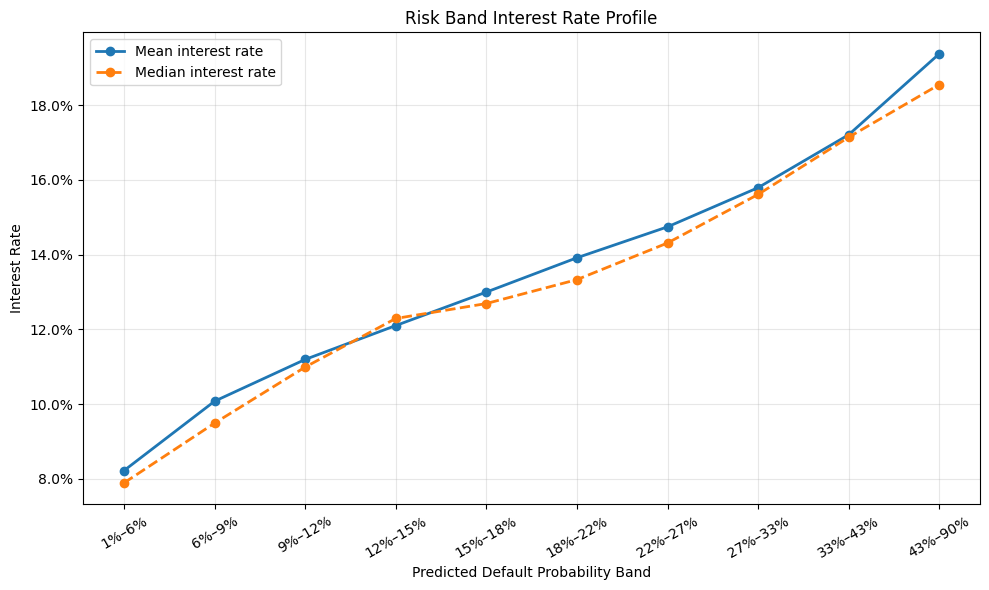

In [25]:
# ----------------------------------------------------------------------
# Build, save, and display risk band summary with pricing (test set)
# ----------------------------------------------------------------------

df_risk_band_summary_test = va.build_risk_band_summary_table(
    df_validation=df_validation_test,
    score_column="predicted_default_probability",
    target_column=metadata["target_column"],
    dataset_name="test",
    n_bands=10,
    interest_rate_column="int_rate",
    log=log,
)

log(
    {
        "stage": "risk_band_summary_with_pricing_built",
        "dataset_name": "test",
        "rows": df_risk_band_summary_test.shape[0],
        "columns": df_risk_band_summary_test.shape[1],
    }
)

risk_band_summary_with_pricing_file = (
    validation_tables_dir / "risk_band_summary_with_pricing_test.csv"
)

df_risk_band_summary_test.to_csv(
    risk_band_summary_with_pricing_file,
    index=False,
)

log(
    {
        "stage": "risk_band_summary_with_pricing_saved",
        "dataset_name": "test",
        "path": str(risk_band_summary_with_pricing_file),
    }
)

# ----------------------------------------------------------------------
# Display (formatted)
# ----------------------------------------------------------------------

df_risk_band_summary_display = df_risk_band_summary_test.copy()

percentage_columns = [
    "predicted_default_probability_mean",
    "observed_default_rate",
    "int_rate_mean",
    "int_rate_median",
]

for column_name in percentage_columns:
    df_risk_band_summary_display[column_name] = (
        df_risk_band_summary_display[column_name]
        .map(lambda value: f"{value:.2%}")
    )

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(df_risk_band_summary_display)

# ----------------------------------------------------------------------
# Build, save, and display risk band interest rate figure (test set)
# ----------------------------------------------------------------------

figure_risk_band_interest_rate_test = vf.plot_risk_band_interest_rate_profile(
    df_risk_band_summary=df_risk_band_summary_test,
    band_column="risk_band",
    mean_interest_rate_column="int_rate_mean",
    median_interest_rate_column="int_rate_median",
    log=log,
)

risk_band_interest_rate_test_file = (
    validation_figures_dir / "risk_band_interest_rate_profile_test.png"
)

figure_risk_band_interest_rate_test.savefig(
    risk_band_interest_rate_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "risk_band_interest_rate_profile_saved",
        "dataset_name": "test",
        "path": str(risk_band_interest_rate_test_file),
    }
)

display(figure_risk_band_interest_rate_test)
plt.close(figure_risk_band_interest_rate_test)

## Interpretation — Risk, Pricing, and Portfolio Outcomes

This analysis compares **predicted risk**, **observed default rates**, and **interest rates** across risk bands derived from the model’s predicted default probabilities. Each band represents borrowers with similar predicted risk at the time of application, allowing direct comparison between realized risk and pricing. Within each band, we evaluate:

- **Observed default rate** → realized borrower risk  
- **Interest rate (mean/median)** → pricing applied to that risk  

The objective is to assess whether pricing scales in line with the underlying risk structure. Interest rates increase monotonically across risk bands, indicating that LendingClub differentiates pricing based on risk. However, pricing increases much more gradually than observed default risk:

- Default risk rises from ~3% to ~43%  
- Interest rates rise from ~8% to ~19%  

This gap becomes most pronounced in the upper risk bands, where default rates accelerate sharply while interest rates increase more slowly. Pricing therefore moves in the correct direction, but does not scale proportionally with risk. This reveals a structural mismatch between risk and pricing. Risk is non-linear and concentrated in the upper tail, while pricing follows a more gradual pattern. As a result, pricing appears relatively weak in the segments where default risk increases most rapidly. This does not imply that pricing is incorrect or that the portfolio is unprofitable, but it indicates that pricing is not tightly aligned with realized risk across the full distribution. The policy analysis shows that portfolio-level outcomes can remain favorable even when pricing is not closely aligned with risk in all segments. This is because:

- Lower- and mid-risk loans contribute stable performance  
- Higher-risk segments represent a smaller share of total exposure  

As a result, outcomes are driven not only by pricing, but also by how capital is distributed across the risk spectrum. The key implication is that the system captures differences in risk, but does not fully align pricing with the shape of that risk. The limitation is therefore not the availability of risk information, but how that information is used in decisions. The model provides a clearer view of the risk distribution, particularly in the upper tail, enabling more targeted decisions in segments where risk increases sharply but pricing does not adjust at the same rate. In other words, the model does not just predict default—it makes visible where pricing and decision rules are not fully aligned with the underlying risk structure.

---

## 5. Decision Synthesis

The previous sections establish three key facts: default risk can be estimated at the time of application, risk increases non-linearly across the loan portfolio, and pricing increases with risk but more gradually, particularly in the upper tail. The task is therefore not to identify risk, but to decide how to act on it. The model produces a predicted default probability for each loan. This is converted into a decision using a threshold: loans at or below the threshold are accepted, and loans above it are rejected. The threshold defines how risk is traded against volume. In practice, the threshold jointly determines three outcomes:

- **Acceptance rate** → how many loans are issued  
- **Default exposure** → how many accepted loans will default  
- **Retained performing loans** → how many good loans are kept  

Changing the threshold shifts all three simultaneously. Lower thresholds (e.g. 0.20–0.30) reduce default exposure but reject a larger share of performing loans, resulting in a more conservative policy. Higher thresholds (e.g. 0.45+) increase acceptance and volume, but admit a disproportionate number of high-risk loans, leading to a more aggressive policy. Policy simulations show that the strongest outcomes occur in the mid-range, centered around **0.35–0.40**. In this region, default exposure remains controlled while a substantial share of performing loans is retained, and outcomes improve relative to the baseline at comparable acceptance levels. Outside this range, the trade-off deteriorates: below ~0.30 the policy becomes overly restrictive, while above ~0.45 exposure to high-risk loans increases rapidly.

This result follows directly from the structure of the loan portfolio. Risk increases non-linearly, with sharp escalation in the upper bands, while pricing increases more gradually in that same region. As a result:

> Additional accepted loans in the upper tail contribute disproportionately to downside risk

A threshold around 0.35–0.40 limits exposure to this segment while preserving volume in lower-risk regions. The limitation of the baseline system is not that it fails to capture risk, but that it operates in discrete categories. Subgrades reflect broad differences in risk but cannot distinguish between borrowers within the same category. The model introduces a continuous risk measure that:

- differentiates borrowers within subgrades  
- identifies higher-risk loans more precisely  
- enables selective exclusion of the upper-risk tail  

This allows capital to be allocated more precisely across the risk distribution. A practical decision rule is therefore:

- Accept loans with predicted default probability ≤ **0.35–0.40**  
- Reject loans above this threshold  

This preserves a large share of performing loans while limiting exposure to segments where risk increases rapidly. The model does not remove the trade-off between risk and volume. It makes that trade-off explicit and controllable, allowing decisions to be aligned directly with estimated risk and enabling more effective allocation of capital across the portfolio.

---

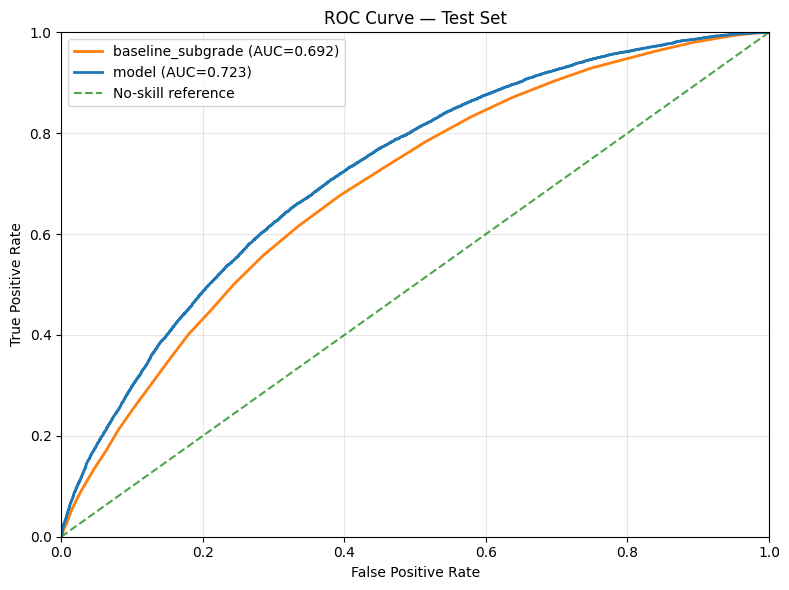

In [26]:
# ----------------------------------------------------------------------
# Report figure 1: ROC curve (test)
# ----------------------------------------------------------------------

figure_report_roc_curve_test = rf.plot_report_roc_curve(
    df_roc_curve_artifact=df_roc_curve_artifact,
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    false_positive_rate_column="false_positive_rate",
    true_positive_rate_column="true_positive_rate",
    auc_column="auc",
    dataset_name="test",
    log=log,
)

report_roc_curve_test_file = report_figures_dir / "report_roc_curve_test.png"

figure_report_roc_curve_test.savefig(
    report_roc_curve_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "report_roc_curve_test_saved",
        "path": str(report_roc_curve_test_file),
    }
)

display(figure_report_roc_curve_test)
plt.close(figure_report_roc_curve_test)

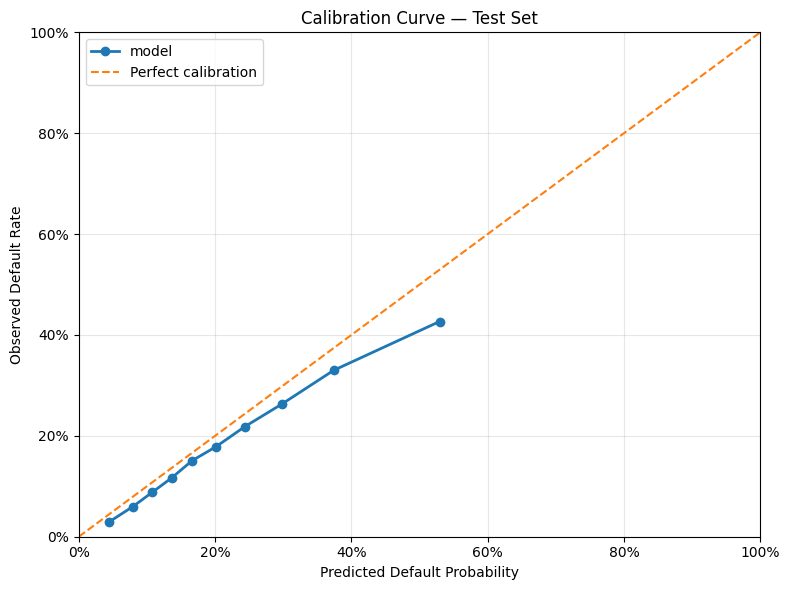

In [27]:
# ----------------------------------------------------------------------
# Report figure 2: Calibration curve (test)
# ----------------------------------------------------------------------

figure_report_calibration_curve_test = rf.plot_report_calibration_curve(
    df_calibration_artifact=df_calibration_artifact,
    dataset_name="test",
    system_name_column="system_name",
    dataset_name_column="dataset_name",
    predicted_probability_column="predicted_probability_mean",
    observed_default_rate_column="observed_default_rate",
    log=log,
)

report_calibration_curve_test_file = (
    report_figures_dir / "report_calibration_curve_test.png"
)

figure_report_calibration_curve_test.savefig(
    report_calibration_curve_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "report_calibration_curve_test_saved",
        "path": str(report_calibration_curve_test_file),
    }
)

display(figure_report_calibration_curve_test)
plt.close(figure_report_calibration_curve_test)

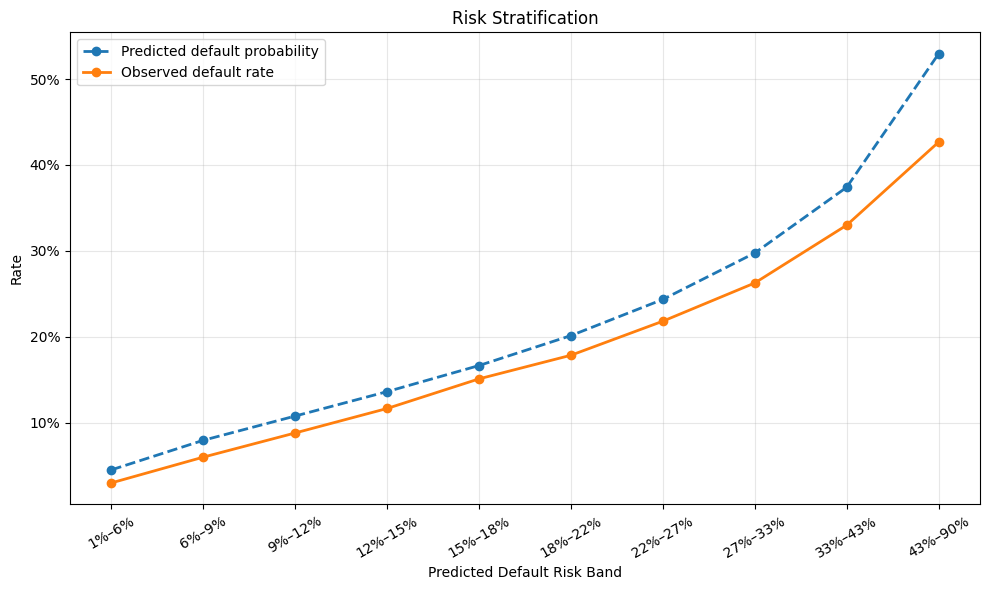

In [28]:
# ----------------------------------------------------------------------
# Report figure 3: Risk stratification (test)
# ----------------------------------------------------------------------

figure_report_risk_stratification_test = rf.plot_report_risk_stratification(
    df_risk_band_summary=df_risk_band_summary_test,
    band_column="risk_band",
    predicted_risk_column="predicted_default_probability_mean",
    observed_default_rate_column="observed_default_rate",
    log=log,
)

report_risk_stratification_test_file = (
    report_figures_dir / "report_risk_stratification_test.png"
)

figure_report_risk_stratification_test.savefig(
    report_risk_stratification_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "report_risk_stratification_test_saved",
        "path": str(report_risk_stratification_test_file),
    }
)

display(figure_report_risk_stratification_test)
plt.close(figure_report_risk_stratification_test)

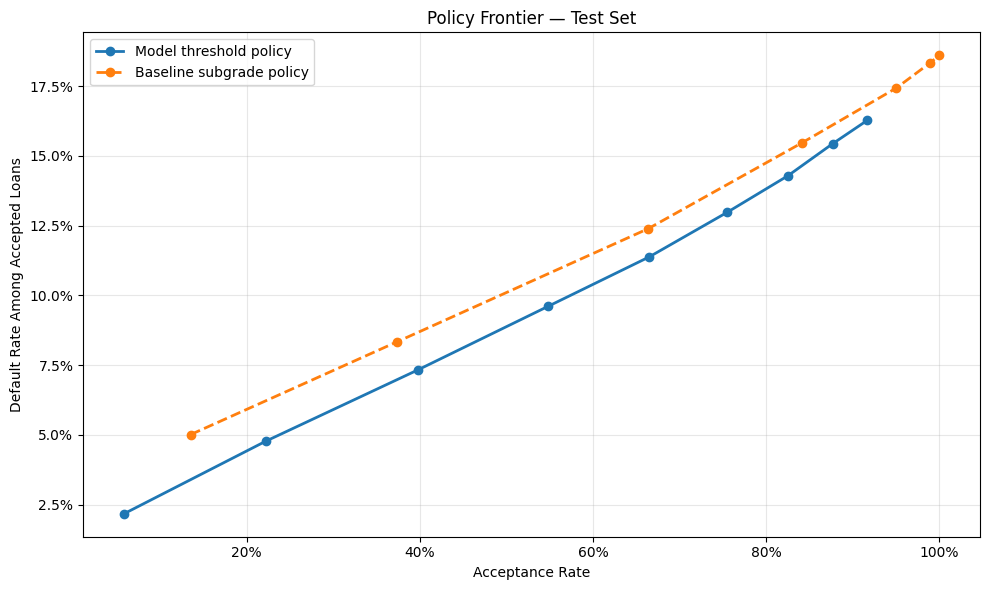

In [29]:
# ----------------------------------------------------------------------
# Report figure 4: Policy frontier (test)
# ----------------------------------------------------------------------

figure_report_policy_frontier_test = rf.plot_report_policy_frontier(
    df_model_policy_outcomes=df_model_policy_outcomes,
    df_baseline_policy_outcomes=df_baseline_policy_outcomes,
    dataset_name="test",
    dataset_name_column="dataset_name",
    acceptance_rate_column="acceptance_rate",
    default_rate_column="default_rate_among_accepted",
    model_label="Model threshold policy",
    baseline_label="Baseline subgrade policy",
    log=log,
)

report_policy_frontier_test_file = (
    report_figures_dir / "report_policy_frontier_test.png"
)

figure_report_policy_frontier_test.savefig(
    report_policy_frontier_test_file,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "report_policy_frontier_test_saved",
        "path": str(report_policy_frontier_test_file),
    }
)

display(figure_report_policy_frontier_test)
plt.close(figure_report_policy_frontier_test)

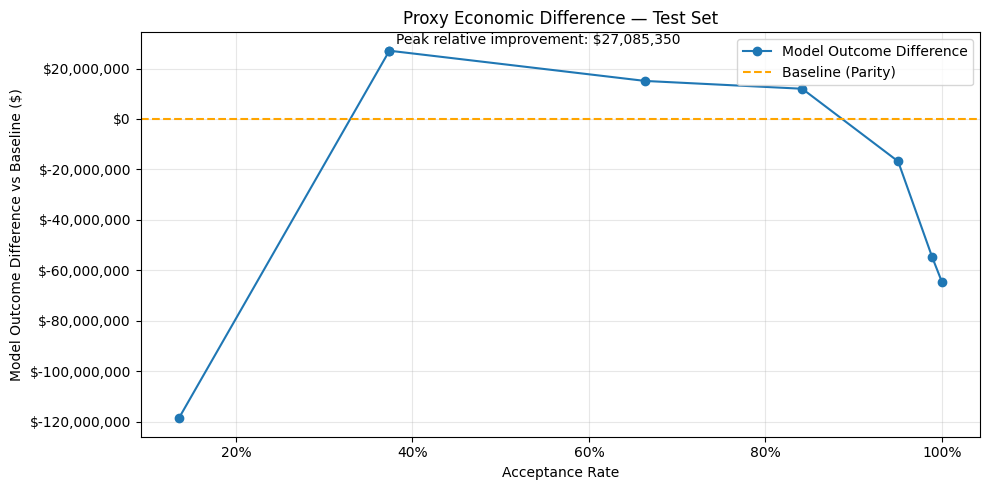

In [30]:
# ----------------------------------------------------------------------
# Report figure 5: Proxy economic comparison (matched policies)
# ----------------------------------------------------------------------

figure_report_proxy_economic_comparison = rf.plot_report_proxy_economic_comparison(
    df_policy_comparison=df_policy_comparison,
    acceptance_rate_column="baseline_acceptance_rate",
    value_diff_column="net_value_with_opportunity_cost_diff",
    title="Proxy Economic Difference — Test Set",
    x_label="Acceptance Rate",
    y_label="Model Advantage ($, with Opportunity Cost)",
    log=log,
)

,Acceptance Rate,Model Threshold,Baseline Proxy Value,Model Proxy Value,Model Advantage,Default Rate Gap
1,37.4%,0.15,"-$180,951,425","-$153,866,075","$27,085,350",-1.02%
2,66.4%,0.25,"$165,629,725","$180,721,725","$15,092,000",-1.02%
3,84.2%,0.35,"$358,623,975","$370,623,300","$11,999,325",-1.18%
4,95.0%,0.45,"$485,660,200","$468,845,250","-$16,814,950",-1.16%
5,98.9%,0.45,"$523,750,250","$468,845,250","-$54,905,000",-2.06%


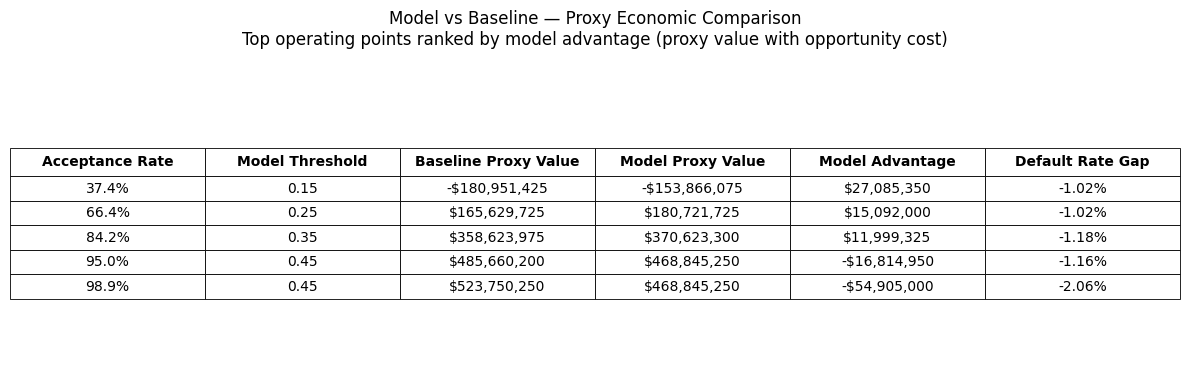

In [31]:
# ---------------------------------------------------------
# Report Figure 6: Build report table (top decision points)
# ---------------------------------------------------------
df_report_policy_table = rf.build_report_policy_comparison_table(
    df_policy_comparison=df_policy_comparison,
    acceptance_rate_column="baseline_acceptance_rate",
    model_threshold_column="model_threshold",
    baseline_value_column="baseline_net_value_with_opportunity_cost",
    model_value_column="model_net_value_with_opportunity_cost",
    value_diff_column="net_value_with_opportunity_cost_diff",
    default_rate_diff_column="default_rate_diff",
    top_n_rows=5,
    sort_by="net_value_with_opportunity_cost_diff",
    ascending=False,
    log=log,
)

display(df_report_policy_table)


# ---------------------------------------------------------
# Render report table figure
# ---------------------------------------------------------
figure_report_policy_table = rf.plot_report_policy_comparison_table(
    df_report_policy_table=df_report_policy_table,
    title="Model vs Baseline — Proxy Economic Comparison",
    subtitle=(
        "Top operating points ranked by model advantage "
        "(proxy value with opportunity cost)"
    ),
    log=log,
)

plt.show()


# ---------------------------------------------------------
# Save report figure (uses your existing directory)
# ---------------------------------------------------------
report_policy_table_path = report_figures_dir / "report_policy_comparison_table.png"

figure_report_policy_table.savefig(
    report_policy_table_path,
    dpi=300,
    bbox_inches="tight",
)

log(
    {
        "stage": "report_policy_comparison_table_saved",
        "path": str(report_policy_table_path),
    }
)

## 6. Outcome — Conclusion

This analysis evaluates whether default risk can be captured using only application-time information and whether that information can be used to improve lending decisions. The results show that default risk can be estimated at the time of application. The model produces a stable and monotonic ordering of borrowers, with a substantial spread between low- and high-risk segments, indicating that risk is both predictable and meaningfully differentiable across the loan portfolio. However, the existing LendingClub system does not fully align with this risk structure. While pricing increases with risk, it does so more gradually than the observed increase in default rates, particularly in the upper tail. This creates segments where loans carry disproportionately high risk relative to their pricing. Policy simulations show that this misalignment has direct decision consequences. The subgrade-based system captures broad differences in risk but lacks the precision to control exposure within grades, resulting in continued allocation to segments where risk is concentrated.

The model-based approach improves on this by introducing a continuous risk measure that enables more targeted decisions. By applying threshold-based policies, exposure to the highest-risk segment can be reduced while preserving a substantial share of performing loans. At comparable acceptance levels in the core operating range (**~0.25–0.35**), the model reduces default rates by approximately **1.0 percentage point**, corresponding to a relative reduction of **~12%** compared to the baseline. Importantly, the economic impact depends on the operating region. At very low acceptance levels, both the model and the baseline generate negative outcomes, and the model’s contribution is best understood as **reducing losses** rather than creating value. The model’s advantage becomes economically meaningful in the mid-range of acceptance thresholds, where outcomes are already positive. In this region, the model improves proxy economic value by approximately **USD 11–15 million** relative to the baseline, reflecting more efficient allocation of capital at similar or higher acceptance levels. At higher acceptance levels, where most loans are approved, the difference between systems diminishes and can reverse, as outcomes become driven more by volume than by selection. These estimates are directional and do not represent a full economic model. The key implication is that the limitation is not the availability of risk information, but how that information is used. The model does not change the structure of the lending trade-off, but makes it explicit and controllable, enabling more effective allocation of capital under uncertainty.